In [1]:
import pandas as pd
import pyarrow as pa
import pyarrow.ipc as ipc
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import time
from typing import Optional

# Create a dictionary of versions
versions = {
    "Python": sys.version.split()[0],
    "Pandas": pd.__version__,
    "NumPy": np.__version__,
    "Matplotlib": plt.matplotlib.__version__,
    "Seaborn": sns.__version__,
    "Pyarrow": pa.__version__
}

# Display as a clean DataFrame
df_versions = pd.DataFrame(list(versions.items()), columns=['Library', 'Version'])
df_versions

,Library,Version
0,Python,3.13.9
1,Pandas,2.3.3
2,NumPy,2.3.4
3,Matplotlib,3.10.7
4,Seaborn,0.13.2
5,Pyarrow,22.0.0


## Read Data
- The Chicago Crime Data contains Crime, Arrest, IUCR, Neighborhood, and Police Beat datasets from the Chicago Crime Portal.

In [2]:
# capture time
start = time.time()
# display all columns
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
# reset options
# pd.reset_option('display.max_columns')

In [3]:
# load using pyarrow for performance (crime data is joined between crime & neighborhood & police using geom)
df_crime = pd.read_csv("../Data/chicago_crimes_export.csv", engine="pyarrow", dtype_backend="pyarrow")

In [4]:
df_crime.head()

,case_number,date,block,iucr,primary_description,secondary_description,index_code,primary_type,description,location_description,arrest,domestic,beat,district,ward,community_area,year,fbi_code,zip_code,zip_code_area,primary_neighborhood,secondary_neighborhood,neighborhood_area,p_district,p_sector,p_beat,arrest_date,race
0,JJ532138,2025-12-23 10:45:00,028XX W TAYLOR ST,2024,NARCOTICS,POSSESS - HEROIN (WHITE),N,NARCOTICS,POSSESS - HEROIN (WHITE),ALLEY,t,f,1135,11,28,27,2025,18,60612,106718949.397,Garfield Park,GARFIELD PARK,89976069.5947,11,3,1135,2025-12-23 10:45:00,WHITE
1,JJ530701,2025-12-22 07:03:00,007XX N FRANKLIN ST,1330,CRIMINAL TRESPASS,TO LAND,N,CRIMINAL TRESPASS,TO LAND,SMALL RETAIL STORE,t,f,1831,18,42,8,2025,26,60654,15869961.5669,River North,RIVER NORTH,38766442.5194,18,3,1831,2025-12-22 07:12:00,BLACK
2,JJ518020,2025-12-10 15:20:00,031XX S ASHLAND AVE,0460,BATTERY,SIMPLE,N,BATTERY,SIMPLE,SMALL RETAIL STORE,t,f,912,9,12,59,2025,08B,60608,176505462.842,Mckinley Park,"BRIGHTON PARK,MCKINLEY PARK",39431799.6479,9,1,912,2025-12-10 17:32:00,BLACK
3,JJ496899,2025-11-21 04:50:00,031XX W HARRISON ST,0454,BATTERY,"AGGRAVATED P.O. - HANDS, FISTS, FEET, NO / MIN...",N,BATTERY,"AGGRAVATED P.O. - HANDS, FISTS, FEET, NO / MIN...",POLICE FACILITY / VEHICLE PARKING LOT,t,f,1134,11,24,27,2025,08B,60612,106718949.397,Garfield Park,GARFIELD PARK,89976069.5947,11,3,1134,2025-11-21 04:15:00,BLACK
4,JJ492148,2025-11-17 06:20:00,035XX N CICERO AVE,0860,THEFT,RETAIL THEFT,I,THEFT,RETAIL THEFT,CONVENIENCE STORE,t,f,1731,17,30,15,2025,06,60641,113903341.241,Portage Park,PORTAGE PARK,110196097.139,17,3,1731,2025-11-17 06:30:00,BLACK


In [5]:
df_crime.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8511080 entries, 0 to 8511079
Data columns (total 28 columns):
 #   Column                  Dtype                
---  ------                  -----                
 0   case_number             string[pyarrow]      
 1   date                    timestamp[s][pyarrow]
 2   block                   string[pyarrow]      
 3   iucr                    string[pyarrow]      
 4   primary_description     string[pyarrow]      
 5   secondary_description   string[pyarrow]      
 6   index_code              string[pyarrow]      
 7   primary_type            string[pyarrow]      
 8   description             string[pyarrow]      
 9   location_description    string[pyarrow]      
 10  arrest                  string[pyarrow]      
 11  domestic                string[pyarrow]      
 12  beat                    int64[pyarrow]       
 13  district                int64[pyarrow]       
 14  ward                    int64[pyarrow]       
 15  community_area 

In [6]:
df_crime.shape

(8511080, 28)

## Check Data

In [7]:
df_crime.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
case_number,8511080,8469443,JD247809,297,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date,8511080,NaN,NaN,NaN,2011-08-16 05:42:21,2001-01-01 00:00:00,2005-06-21 15:45:00,2010-06-25 13:30:00,2017-06-08 02:46:00,2025-12-24 00:00:00,NaN
block,8511080,65510,001XX N STATE ST,17259,NaN,NaN,NaN,NaN,NaN,NaN,NaN
iucr,8511080,418,0820,679816,NaN,NaN,NaN,NaN,NaN,NaN,NaN
primary_description,8496103,32,THEFT,1793795,NaN,NaN,NaN,NaN,NaN,NaN,NaN
secondary_description,8496103,369,SIMPLE,998931,NaN,NaN,NaN,NaN,NaN,NaN,NaN
index_code,8496103,2,N,5035937,NaN,NaN,NaN,NaN,NaN,NaN,NaN
primary_type,8511080,34,THEFT,1801870,NaN,NaN,NaN,NaN,NaN,NaN,NaN
description,8511080,569,SIMPLE,998931,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location_description,8495739,218,STREET,2226072,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## User Function(s)

In [8]:
def any_nans(data):
    # .sum() on PyArrow columns is very fast
    null_counts = data.isnull().sum()
    null_counts = null_counts[null_counts > 0]
    
    if not null_counts.empty:
        print("NaNs with Columns Name and Count:")
        # Adding percentage helps put the 8.4M rows into perspective
        percent = (null_counts / len(data)) * 100
        out = pd.DataFrame({'Count': null_counts, 'Percentage': percent.round(4)})
        print(out)
    else:
        print("No NaNs found")

## Data Wrangle
- Chicago's `IUCR` codes (Illinois Uniform Crime Reporting) are four-digit codes for classifying crimes, with the Chicago Police Department (CPD) using over 400, including FBI Index Offenses (homicide, robbery, theft) and Non-Index offenses (vandalism, weapons violations)
- Chicago has `50 wards`, each represented by an alderperson, with boundaries redrawn every eight years
- The Chicago Police Department (CPD) divides the city into `22 Districts`, which are further broken down into smaller patrol zones called `Beats`, with specific 4-digit numbers for each area
- Chicago is divided into `77 official Community Areas`

In [9]:
# get dupes
dupes = df_crime.duplicated()
# any duplicates
if dupes.any():
    print(f"Number of Duplicates: {dupes.sum():,}")
else:
    print("No Duplicates")

Number of Duplicates: 24,983


In [10]:
df_crime[dupes].head()

,case_number,date,block,iucr,primary_description,secondary_description,index_code,primary_type,description,location_description,arrest,domestic,beat,district,ward,community_area,year,fbi_code,zip_code,zip_code_area,primary_neighborhood,secondary_neighborhood,neighborhood_area,p_district,p_sector,p_beat,arrest_date,race
100,JJ241687,2025-05-03 23:40:00,018XX S KARLOV AVE,1480,CONCEALED CARRY LICENSE VIOLATION,OTHER,N,CONCEALED CARRY LICENSE VIOLATION,OTHER,STREET,t,f,1012,10,24,29,2025,15,60623,155285530.844,North Lawndale,NORTH LAWNDALE,89487422.0244,10,1,1012,2025-05-03 23:41:00,BLACK
132,JJ386981,2025-08-23 22:17:00,047XX W NORTH AVE,0860,THEFT,RETAIL THEFT,I,THEFT,RETAIL THEFT,SIDEWALK,t,f,2533,25,37,25,2025,06,60639,127476051.26,Austin,AUSTIN,170037750.826,25,3,2533,2025-08-23 22:32:00,BLACK
143,JJ183724,2025-03-16 13:44:00,025XX W WASHINGTON BLVD,0610,BURGLARY,FORCIBLE ENTRY,I,BURGLARY,FORCIBLE ENTRY,OTHER RAILROAD PROPERTY / TRAIN DEPOT,t,f,1222,12,27,28,2025,05,60612,106718949.397,United Center,UNITED CENTER,32520512.7053,12,2,1222,2025-03-16 14:06:00,BLACK
151,JH550982,2024-12-21 12:58:00,003XX E 115TH ST,1220,DECEPTIVE PRACTICE,THEFT OF LOST / MISLAID PROPERTY,N,DECEPTIVE PRACTICE,THEFT OF LOST / MISLAID PROPERTY,STREET,t,f,532,5,9,53,2024,11,60628,345241691.573,Roseland,"WASHINGTON HEIGHTS,ROSELAND",134313706.73,5,3,531,2024-12-21 13:14:00,BLACK
152,JH550982,2024-12-21 12:58:00,003XX E 115TH ST,1220,DECEPTIVE PRACTICE,THEFT OF LOST / MISLAID PROPERTY,N,DECEPTIVE PRACTICE,THEFT OF LOST / MISLAID PROPERTY,STREET,t,f,532,5,9,53,2024,11,60628,345241691.573,Roseland,"WASHINGTON HEIGHTS,ROSELAND",134313706.73,5,3,531,2024-12-21 13:14:00,BLACK


In [11]:
# num of rows before 
before = df_crime.shape[0]
# remove any duplicates
df_crime = df_crime.drop_duplicates().reset_index(drop=True)
# num of rows after 
after = df_crime.shape[0]
print(f"Duplicate Rows Removed: {(before - after):,}")
print(f"Shape: {df_crime.shape[0]:,} Rows & {df_crime.shape[1]:,} Columns")

Duplicate Rows Removed: 24,983
Shape: 8,486,097 Rows & 28 Columns


In [12]:
# display number of unique values
for i in df_crime.columns:
    print(f"{i}: {df_crime[i].nunique():,}")

case_number: 8,469,443
date: 3,545,853
block: 65,510
iucr: 418
primary_description: 32
secondary_description: 369
index_code: 2
primary_type: 34
description: 569
location_description: 218
arrest: 2
domestic: 2
beat: 305
district: 24
ward: 50
community_area: 78
year: 25
fbi_code: 26
zip_code: 59
zip_code_area: 59
primary_neighborhood: 98
secondary_neighborhood: 78
neighborhood_area: 98
p_district: 23
p_sector: 5
p_beat: 275
arrest_date: 371,755
race: 7


In [13]:
# display null columns
any_nans(df_crime)

NaNs with Columns Name and Count:
                          Count  Percentage
primary_description       14972      0.1764
secondary_description     14972      0.1764
index_code                14972      0.1764
location_description      15339      0.1808
district                     47      0.0006
ward                     614812      7.2449
community_area           613679      7.2316
zip_code                 116470      1.3725
zip_code_area            116470      1.3725
primary_neighborhood     116526      1.3731
secondary_neighborhood   116526      1.3731
neighborhood_area        116526      1.3731
p_district               115247      1.3581
p_sector                 115247      1.3581
p_beat                   115247      1.3581
arrest_date             8084606     95.2688
race                    8084606     95.2688


In [14]:
print(sorted(df_crime['fbi_code'].unique()))

['01A', '01B', '02', '03', '04A', '04B', '05', '06', '07', '08A', '08B', '09', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '22', '24', '26']


In [15]:
# mapping for fbi codes
mapping = {
  "01A": "Homicide – 1st or 2nd Degree",
  "01B": "Involuntary Manslaughter / Reckless Homicide",
  "02":  "Criminal Sexual Assault",
  "03":  "Robbery",
  "04A": "Aggravated Assault",
  "04B": "Aggravated Battery",
  "05":  "Burglary",
  "06":  "Larceny – Theft",
  "07":  "Motor Vehicle Theft",
  "09":  "Arson",
  "08A": "Simple Assault",
  "08B": "Simple Battery",
  "10":  "Forgery and Counterfeiting",
  "11":  "Fraud",
  "12":  "Embezzlement",
  "13":  "Stolen Property (Buy, Receive, Possess)",
  "14":  "Vandalism",
  "15":  "Weapons Violations",
  "16":  "Prostitution",
  "17":  "Sex Offense – Criminal Sexual Abuse",
  "18":  "Drug Abuse Violations",
  "19":  "Gambling",
  "20":  "Offenses Against Family and Children",
  "22":  "Liquor Laws",
  "24":  "Disorderly Conduct",
  "26":  "Miscellaneous Non-Index Offenses"
}

In [16]:
# determine specific values in the data are missing from mapping dictionary
df_crime.loc[df_crime.fbi_code.map(mapping).isna(), "fbi_code"].unique()

<ArrowExtensionArray>
[]
Length: 0, dtype: string[pyarrow]

In [17]:
# add new column
df_crime["fbi_code_desc"] = (
    df_crime.fbi_code
    .map(mapping)
    .astype("string[pyarrow]")
)

# Force fbi_code_desc to use the exact same dtype object as fbi_code
df_crime["fbi_code_desc"] = df_crime["fbi_code_desc"].astype(df_crime["fbi_code"].dtype)

In [18]:
# df_crime[['iucr','primary_description','secondary_description','description','fbi_code']][df_crime['fbi_code'] == '01A'].sample(5)
df_crime[['iucr','primary_description','secondary_description','description','fbi_code_desc', 'fbi_code','index_code']].sample(5)

,iucr,primary_description,secondary_description,description,fbi_code_desc,fbi_code,index_code
3166549,0430,BATTERY,AGGRAVATED - OTHER DANGEROUS WEAPON,AGGRAVATED: OTHER DANG WEAPON,Aggravated Battery,04B,I
581144,0890,THEFT,FROM BUILDING,FROM BUILDING,Larceny – Theft,06,I
670342,0560,ASSAULT,SIMPLE,SIMPLE,Simple Assault,08A,N
1036765,2024,NARCOTICS,POSSESS - HEROIN (WHITE),POSS: HEROIN(WHITE),Drug Abuse Violations,18,N
3923792,1310,CRIMINAL DAMAGE,TO PROPERTY,TO PROPERTY,Vandalism,14,N


In [19]:
# check for unique values
df_crime[['arrest','domestic']].apply(lambda s: s.unique())

,arrest,domestic
0,t,f
1,f,t


In [20]:
# convert to pyarrow boolean
df_crime[['arrest','domestic']] = (
    df_crime[['arrest','domestic']] # domestic: Domestic violence
        .apply(lambda col: col.map({'t': True, 'f': False}))
        .astype('boolean[pyarrow]')
)

#### Feature Information:
- A Chicago `ward` is one of 50 legislative districts, each represented by an elected Alderman on the City Council, serving as local government branches to provide city services, manage development, and reflect community demographics, with boundaries redrawn every 10 years based on census data
- The `district` feature refers to the city's 22 police districts, which are geographic areas used to organize crime data
- The `beat` feature in Chicago crime data identifies the smallest geographic police area (a beat) where a crime occurred
- The `sector` refers to a specific geographic division used by the Chicago Police Department (CPD), where several smaller `beats` (police patrol areas) are grouped together to form a sector, which then rolls up into a larger `district`, providing a layered geographic context for analyzing crime trends
- The `Community Area` feature refers to one of 77 distinct, officially defined, and geographically stable neighborhoods used for urban planning and statistical analysis. This feature allows categorizing crime incidents by location, enabling trend analysis and identifying high-crime areas

In [21]:
print(sorted(df_crime.district.fillna(-1).unique()))
print(sorted(df_crime.p_district.fillna(-1).unique()))

[-1, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 24, 25, 31]
[-1, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 22, 24, 25, 31]


In [22]:
df_crime.district.isnull().sum(), df_crime.p_district.isna().sum(), df_crime.p_sector.isna().sum(), df_crime.community_area.isna().sum()

(np.int64(47), np.int64(115247), np.int64(115247), np.int64(613679))

In [23]:
df_crime[['year', 'fbi_code_desc', 'ward', 'beat', 'p_beat', 'district', 'p_district', 'p_sector']][df_crime.district.isna()]

,year,fbi_code_desc,ward,beat,p_beat,district,p_district,p_sector
67098,2008,Aggravated Assault,20,313,313,<NA>,3,1
588710,2008,Burglary,8,411,411,<NA>,4,1
779071,2008,Robbery,27,1112,1112,<NA>,11,1
861106,2008,Criminal Sexual Assault,17,734,734,<NA>,7,3
949128,2008,Larceny – Theft,42,1834,1834,<NA>,18,3
1106888,2007,Embezzlement,11,922,913,<NA>,9,1
1173059,2008,Simple Battery,22,1013,1013,<NA>,10,1
1275682,2008,Miscellaneous Non-Index Offenses,36,2511,2511,<NA>,25,1
1294828,2008,Sex Offense – Criminal Sexual Abuse,44,1924,1924,<NA>,19,2
1640890,2008,Motor Vehicle Theft,38,1624,1633,<NA>,16,3


In [24]:
# update district with p_district from police beats table
mask = df_crime['district'].isna()
df_crime.loc[mask, 'district'] = df_crime.loc[mask, 'p_district']

In [25]:
# District 21 does not exist per 'https://www.chicagopolice.org/statistics-data/crime-statistics/'
mask_21 = df_crime.district == 21
# df_crime.drop(index=idx, inplace=True)
df_crime.loc[mask_21,['year','zip_code', 'ward', 'community_area', 'primary_neighborhood', 'secondary_neighborhood', 'fbi_code_desc', 'district', 'p_district']]

,year,zip_code,ward,community_area,primary_neighborhood,secondary_neighborhood,fbi_code_desc,district,p_district
874831,2004,60616,3,35,Douglas,BRONZEVILLE,Drug Abuse Violations,21,2
3496885,2004,60616,3,35,Douglas,BRONZEVILLE,Aggravated Battery,21,2
7075541,2003,60616,3,35,Douglas,BRONZEVILLE,Larceny – Theft,21,2
8241338,2004,60616,3,35,Douglas,BRONZEVILLE,Simple Battery,21,2


In [26]:
# update invalid district with district from police beats table 
df_crime.loc[mask_21, 'district'] = df_crime.loc[mask, 'p_district'] .sample(10)

In [27]:
# District 31 does not exist per 'https://www.chicagopolice.org/statistics-data/crime-statistics/'
mask_31 = df_crime.district == 31
# df_crime.drop(index=idx, inplace=True)
df_crime.loc[mask_31,['year', 'zip_code', 'primary_neighborhood', 'secondary_neighborhood', 'district', 'p_district', 'fbi_code_desc']].sort_values(by=['year', 'zip_code'], ascending=False)

,year,zip_code,primary_neighborhood,secondary_neighborhood,district,p_district,fbi_code_desc
732302,2025,60666,O'Hare,OHARE,31,16,Miscellaneous Non-Index Offenses
1027118,2025,60666,O'Hare,OHARE,31,16,Simple Assault
1406246,2025,60666,O'Hare,OHARE,31,16,Miscellaneous Non-Index Offenses
2188563,2025,60666,O'Hare,OHARE,31,16,Simple Battery
2802133,2025,60666,O'Hare,OHARE,31,16,Vandalism
3401693,2025,60666,O'Hare,OHARE,31,16,Miscellaneous Non-Index Offenses
3444426,2025,60666,O'Hare,OHARE,31,16,Simple Assault
7459702,2025,60666,O'Hare,OHARE,31,16,Simple Battery
87411,2025,60626,Rogers Park,ROGERS PARK,31,24,Drug Abuse Violations
752201,2025,<NA>,<NA>,<NA>,31,<NA>,Simple Assault


In [28]:
# update invalid district 31 with p_district
df_crime.loc[mask_31, 'district'] = df_crime.loc[mask_31, 'p_district']

In [29]:
# list all district 31 after cleaning
df_crime.loc[df_crime.district == 31 ,['year', 'zip_code', 'primary_neighborhood', 'secondary_neighborhood', 'district', 'p_district', 'fbi_code_desc']] \
    .sort_values(by=['year', 'zip_code'], ascending=False)

,year,zip_code,primary_neighborhood,secondary_neighborhood,district,p_district,fbi_code_desc
839931,2022,<NA>,<NA>,<NA>,31,31,"Stolen Property (Buy, Receive, Possess)"
1880538,2022,<NA>,<NA>,<NA>,31,31,Larceny – Theft
2167960,2022,<NA>,<NA>,<NA>,31,31,Larceny – Theft
2538770,2022,<NA>,<NA>,<NA>,31,31,"Stolen Property (Buy, Receive, Possess)"
3872354,2022,<NA>,<NA>,<NA>,31,31,"Stolen Property (Buy, Receive, Possess)"
7969785,2022,<NA>,<NA>,<NA>,31,31,"Stolen Property (Buy, Receive, Possess)"
8165480,2022,<NA>,<NA>,<NA>,31,31,"Stolen Property (Buy, Receive, Possess)"
3353103,2021,<NA>,<NA>,<NA>,31,31,Sex Offense – Criminal Sexual Abuse
4061518,2021,<NA>,<NA>,<NA>,31,31,Criminal Sexual Assault
1448619,2018,<NA>,<NA>,<NA>,31,31,Sex Offense – Criminal Sexual Abuse


In [30]:
# update invalid district 31 to NaNs
df_crime.loc[df_crime["district"] == 31, "district"] = pd.NA

In [31]:
# change to string and must be three char length
cols = ['district', 'p_district', 'beat', 'p_beat', 'ward', 'community_area', 'p_sector', 'year', 'zip_code']

# iterate cols
for col in cols:

    if col in ['district','p_district']:
        # Fill NAs and convert to a standard string for the zfill operation
        df_crime[col] = df_crime[col].fillna(0).astype("string").str.zfill(3)
    else:
        # Fill NAs and convert to a standard string
        df_crime[col] = df_crime[col].fillna(0).astype("string")
        
    # Force the exact ArrowDtype
    df_crime[col] = df_crime[col].astype(pd.ArrowDtype(pa.string()))

df_crime[cols].sample(5)

,district,p_district,beat,p_beat,ward,community_area,p_sector,year,zip_code
6954084,025,025,2533,2533,37,25,3,2019,60651
195232,018,018,1812,1812,43,7,1,2004,60614
3435803,017,017,1733,1733,35,21,3,2004,60618
4892849,011,011,1112,1112,27,23,1,2002,60651
1708106,018,018,1821,1823,27,8,2,2004,60610


In [32]:
# Add Month & Day of the Week
months = ['January', 'February', 'March', 'April', 'May', 'June', 
          'July', 'August', 'September', 'October', 'November', 'December']
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Extract integers and map them
# .dt.month returns 1-12, so we subtract 1 for 0-based indexing
df_crime['month'] = np.array(months)[df_crime['date'].dt.month.values - 1]

# .dt.dayofweek returns 0-6 (0 is Monday)
df_crime['day_of_week'] = np.array(days)[df_crime['date'].dt.dayofweek.values]

# convert to pyarrow
df_crime['month'] = df_crime['month'].astype(pd.ArrowDtype(pa.string()))
df_crime['day_of_week'] = df_crime['day_of_week'].astype(pd.ArrowDtype(pa.string()))

In [33]:
# Map to strings first
df_crime['quarter'] = df_crime['date'].dt.quarter.map({1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'}).astype(pd.ArrowDtype(pa.string()))

# Vectorized concatenation of Year + '-' + Quarter
# Cast year to a string and combine it with the quarter string
combined_series = (df_crime['year'] + "-" + df_crime['quarter'])

# Creates the indices and the dictionary table in one step
df_crime['year_quarter'] = combined_series
df_crime['year_quarter'] = df_crime['year_quarter'].astype(pd.ArrowDtype(pa.string()))

| Interval (Inclusive, Exclusive) | Mathematical Notation | Label        | Hours Included    |
|--------------------------------|----------------------|--------------|-------------------|
| 1st: 0 to 4                    | \([0, 4)\)          | Late Night   | 0, 1, 2, 3       |
| 2nd: 4 to 8                    | \([4, 8)\)          | Early Morning| 4, 5, 6, 7       |
| 3rd: 8 to 12                   | \([8, 12)\)         | Morning      | 8, 9, 10, 11     |
| 4th: 12 to 16                  | \([12, 16)\)        | Afternoon    | 12, 13, 14, 15   |
| 5th: 16 to 20                  | \([16, 20)\)        | Evening      | 16, 17, 18, 19   |
| 6th: 20 to 24                  | \([20, 24)\)        | Night        | 20, 21, 22, 23   |

In [34]:
# Get the hours as a PyArrow-backed integer
hours = df_crime['date'].dt.hour.values

# Use np.digitize for ultra-fast binning (vectorized)
# bins: [0, 4, 8, 12, 16, 20, 24]
# digitize returns 1 for 0-3, 2 for 4-7, etc.
bin_indices = np.digitize(hours, bins=[4, 8, 12, 16, 20])

# Map indices to labels
time_labels = np.array(['Late Night', 'Early Morning', 'Morning', 'Afternoon', 'Evening', 'Night'])
df_crime['time_of_day'] = time_labels[bin_indices]

# Final cast to string[pyarrow]
df_crime['time_of_day'] = df_crime['time_of_day'].astype(pd.ArrowDtype(pa.string()))

In [35]:
df_crime[['date', 'time_of_day']].sample(10)

,date,time_of_day
4943899,2013-12-03 18:30:00,Evening
5758067,2013-03-25 21:41:00,Night
4922815,2001-04-04 08:00:00,Morning
4249806,2005-02-25 09:40:00,Morning
3429625,2015-11-26 02:58:00,Late Night
7455989,2009-02-28 08:55:00,Morning
3736859,2006-11-30 20:32:53,Night
7762815,2003-09-13 00:15:00,Late Night
6315405,2025-08-30 01:27:00,Late Night
2187161,2017-02-05 20:45:00,Night


In [36]:
df_crime.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8486097 entries, 0 to 8486096
Data columns (total 34 columns):
 #   Column                  Dtype                
---  ------                  -----                
 0   case_number             string[pyarrow]      
 1   date                    timestamp[s][pyarrow]
 2   block                   string[pyarrow]      
 3   iucr                    string[pyarrow]      
 4   primary_description     string[pyarrow]      
 5   secondary_description   string[pyarrow]      
 6   index_code              string[pyarrow]      
 7   primary_type            string[pyarrow]      
 8   description             string[pyarrow]      
 9   location_description    string[pyarrow]      
 10  arrest                  bool[pyarrow]        
 11  domestic                bool[pyarrow]        
 12  beat                    string[pyarrow]      
 13  district                string[pyarrow]      
 14  ward                    string[pyarrow]      
 15  community_area 

In [37]:
# collapse fragmented blocks internally
df_crime._consolidate_inplace()
# display
df_crime.head()

,case_number,date,block,iucr,primary_description,secondary_description,index_code,primary_type,description,location_description,arrest,domestic,beat,district,ward,community_area,year,fbi_code,zip_code,zip_code_area,primary_neighborhood,secondary_neighborhood,neighborhood_area,p_district,p_sector,p_beat,arrest_date,race,fbi_code_desc,month,day_of_week,quarter,year_quarter,time_of_day
0,JJ532138,2025-12-23 10:45:00,028XX W TAYLOR ST,2024,NARCOTICS,POSSESS - HEROIN (WHITE),N,NARCOTICS,POSSESS - HEROIN (WHITE),ALLEY,True,False,1135,011,28,27,2025,18,60612,106718949.397,Garfield Park,GARFIELD PARK,89976069.5947,011,3,1135,2025-12-23 10:45:00,WHITE,Drug Abuse Violations,December,Tuesday,Q4,2025-Q4,Morning
1,JJ530701,2025-12-22 07:03:00,007XX N FRANKLIN ST,1330,CRIMINAL TRESPASS,TO LAND,N,CRIMINAL TRESPASS,TO LAND,SMALL RETAIL STORE,True,False,1831,018,42,8,2025,26,60654,15869961.5669,River North,RIVER NORTH,38766442.5194,018,3,1831,2025-12-22 07:12:00,BLACK,Miscellaneous Non-Index Offenses,December,Monday,Q4,2025-Q4,Early Morning
2,JJ518020,2025-12-10 15:20:00,031XX S ASHLAND AVE,0460,BATTERY,SIMPLE,N,BATTERY,SIMPLE,SMALL RETAIL STORE,True,False,912,009,12,59,2025,08B,60608,176505462.842,Mckinley Park,"BRIGHTON PARK,MCKINLEY PARK",39431799.6479,009,1,912,2025-12-10 17:32:00,BLACK,Simple Battery,December,Wednesday,Q4,2025-Q4,Afternoon
3,JJ496899,2025-11-21 04:50:00,031XX W HARRISON ST,0454,BATTERY,"AGGRAVATED P.O. - HANDS, FISTS, FEET, NO / MIN...",N,BATTERY,"AGGRAVATED P.O. - HANDS, FISTS, FEET, NO / MIN...",POLICE FACILITY / VEHICLE PARKING LOT,True,False,1134,011,24,27,2025,08B,60612,106718949.397,Garfield Park,GARFIELD PARK,89976069.5947,011,3,1134,2025-11-21 04:15:00,BLACK,Simple Battery,November,Friday,Q4,2025-Q4,Early Morning
4,JJ492148,2025-11-17 06:20:00,035XX N CICERO AVE,0860,THEFT,RETAIL THEFT,I,THEFT,RETAIL THEFT,CONVENIENCE STORE,True,False,1731,017,30,15,2025,06,60641,113903341.241,Portage Park,PORTAGE PARK,110196097.139,017,3,1731,2025-11-17 06:30:00,BLACK,Larceny – Theft,November,Monday,Q4,2025-Q4,Early Morning


In [38]:
# check for nans
any_nans(df_crime)

NaNs with Columns Name and Count:
                          Count  Percentage
primary_description       14972      0.1764
secondary_description     14972      0.1764
index_code                14972      0.1764
location_description      15339      0.1808
zip_code_area            116470      1.3725
primary_neighborhood     116526      1.3731
secondary_neighborhood   116526      1.3731
neighborhood_area        116526      1.3731
arrest_date             8084606     95.2688
race                    8084606     95.2688


## Visualize (2001 - 2025)

### User Function(s)

In [39]:
def line_plot(data: pd.DataFrame, column_name: str, category_name: str, numeric_name: str) -> None:
    """
    Creates a faceted line plot for time-series crime data with peak indicators.

    This function generates a grid of subplots (one for each unique value in column_name),
    draws a line plot showing trends over category_name, and marks the maximum 
    value in each facet with a vertical dashed line.

    Args:
        data (pd.DataFrame): The tidy (long-form) DataFrame containing the data.
        column_name (str): The column used to create the grid (e.g., 'fbi_code_desc').
        category_name (str): The x-axis variable (e.g., 'month' or 'quarter').
        numeric_name (str): The y-axis variable (e.g., 'count').

    Returns:
        None: Displays the plot using plt.show().
    """
    # 1. Create the FacetGrid
    # We use 'sharex=True' to keep category alignment but 'sharey=False' 
    # to see trends in low-volume categories.
    g = sns.FacetGrid(
        data,
        col=column_name,
        col_wrap=4,
        hue=column_name,
        sharey=False,
        height=4,
        aspect=1.2
    )
    
    # 2. Map the lineplot
    g.map(sns.lineplot, category_name, numeric_name, marker='o')
    
    # 3. Optimize: Use GroupBy to avoid repeated manual filtering
    # This aligns the vertical lines perfectly with the faceted plots.
    grouped = data.groupby(column_name, sort=False)
    
    for ax, (name, facet_data) in zip(g.axes.flatten(), grouped):
        if not facet_data.empty:
            # Find the peak
            max_idx = facet_data[numeric_name].idxmax()
            max_cat = facet_data.loc[max_idx, category_name]
            peak_val = facet_data.loc[max_idx, numeric_name]
            
            # Vertical line and Peak label
            ax.axvline(x=max_cat, color='black', linestyle='--', alpha=0.5, zorder=0)
            ax.text(
                x=max_cat, 
                y=peak_val, 
                s=f' {peak_val:,.0f}', 
                va='bottom', 
                fontsize=9, 
                fontweight='bold',
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1)
            )

        # 4. Force x-labels on EVERY subplot
        ax.tick_params(labelbottom=True)
        # Apply labels and rotation
        ax.set_xlabel(category_name.capitalize())
        ax.set_ylabel(numeric_name.capitalize())
        plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

    # 5. Add Title
    g.set_titles("{col_name}")
    
    # Tight layout handles spacing, but we add hspace for the extra x-labels
    plt.subplots_adjust(hspace=0.7)
    g.tight_layout()
    plt.show()


def stacked_bar_plot(data, title='Relative Distribution of Crimes Across Quarters (%)',  figsize=(12, 8), cmap='Set2', sort_index=True):
    """
    Generates a horizontal stacked bar chart showing percentage distribution per row,
    sorted alphabetically by the index.

    Args:
        data (pd.DataFrame): DataFrame where index is the category and columns are sub-groups.
        title (str): The title of the plot.
        cmap (str): The Matplotlib colormap name.
        sort_index (bool): If True, sorts the y-axis alphabetically (A-Z from top to bottom).

    Returns:
        None: Displays a Matplotlib plot.
    """
    # 1. Sort Data by Index
    # ascending=False ensures 'A' is at the top and 'Z' is at the bottom in barh
    if sort_index:
        data = data.sort_index(ascending=False)

    # 2. Calculate row-wise percentages
    data_pct = data.div(data.sum(axis=1), axis=0) * 100
    
    # 3. Setup the figure and primary plot
    ax = data_pct.plot(
        kind='barh', 
        stacked=True, 
        figsize=figsize, 
        colormap=cmap,
        edgecolor='white', 
        linewidth=0.5
    )
    
    # 4. Pre-calculate the maximum column for each row for highlighting
    max_cols = data_pct.idxmax(axis=1)
    
    # 5. Annotate bar segments
    for i, container in enumerate(ax.containers):
        col_name = data_pct.columns[i]
        
        for j, bar in enumerate(container):
            width = bar.get_width()
            if width <= 2.0: # Skip labels for tiny segments to prevent clutter
                continue
            
            is_max = (col_name == max_cols.iloc[j])
            text_color = 'red' if is_max else 'white'
            
            ax.text(
                bar.get_x() + width/2, 
                bar.get_y() + bar.get_height()/2, 
                f'{width:.1f}%', 
                ha='center', 
                va='center', 
                color=text_color, 
                weight='bold' if is_max else 'normal',
                fontsize=9
            )
    
    # 6. Aesthetics
    plt.title(title, fontsize=14, pad=15)
    plt.xlabel('Percentage of Total Count', fontweight='bold')
    plt.ylabel('FBI Crime Type', fontweight='bold')
    plt.legend(title='Quarter', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
    plt.xlim(0, 100)
    plt.tight_layout()
    plt.show()

### Plots

In [40]:
# create a crosstab of crime counts by year and FBI code description
crime_year = df_crime.groupby(['year','fbi_code_desc']).size().reset_index(name='count')
# pivot table
pivot_year = crime_year.pivot(index='fbi_code_desc', columns='year', values='count').sort_index().fillna(0)
# display
pivot_year.head()

year,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
fbi_code_desc,,,,,,,,,,,,,,,,,,,,,,,,,
Aggravated Assault,7872.0,7721.0,7372.0,7331.0,6754.0,6597.0,6335.0,6250.0,6000.0,5278.0,5157.0,4873.0,4269.0,4371.0,4481.0,5765.0,5828.0,6046.0,5882.0,6302.0,7265.0,7313.0,7758.0,7948.0,6499.0
Aggravated Battery,16396.0,15196.0,12478.0,11530.0,11329.0,11007.0,11154.0,10805.0,10142.0,9432.0,8403.0,8005.0,6636.0,6647.0,7023.0,8144.0,7901.0,7794.0,7925.0,8391.0,8391.0,7542.0,8123.0,8243.0,7039.0
Arson,1011.0,1032.0,955.0,778.0,691.0,726.0,712.0,644.0,616.0,522.0,504.0,469.0,364.0,397.0,454.0,521.0,446.0,373.0,377.0,590.0,531.0,424.0,514.0,482.0,368.0
Burglary,26014.0,25623.0,25157.0,24564.0,25503.0,24324.0,24858.0,26218.0,26767.0,26422.0,26620.0,22845.0,17895.0,14635.0,13185.0,14362.0,13045.0,11791.0,9682.0,8855.0,6676.0,7611.0,7515.0,7685.0,6086.0
Criminal Sexual Assault,2198.0,2222.0,2003.0,1950.0,1916.0,1814.0,1884.0,1808.0,1700.0,1643.0,1741.0,1704.0,1575.0,1650.0,1720.0,1880.0,2006.0,2068.0,1937.0,1514.0,1773.0,1853.0,1889.0,1793.0,1741.0


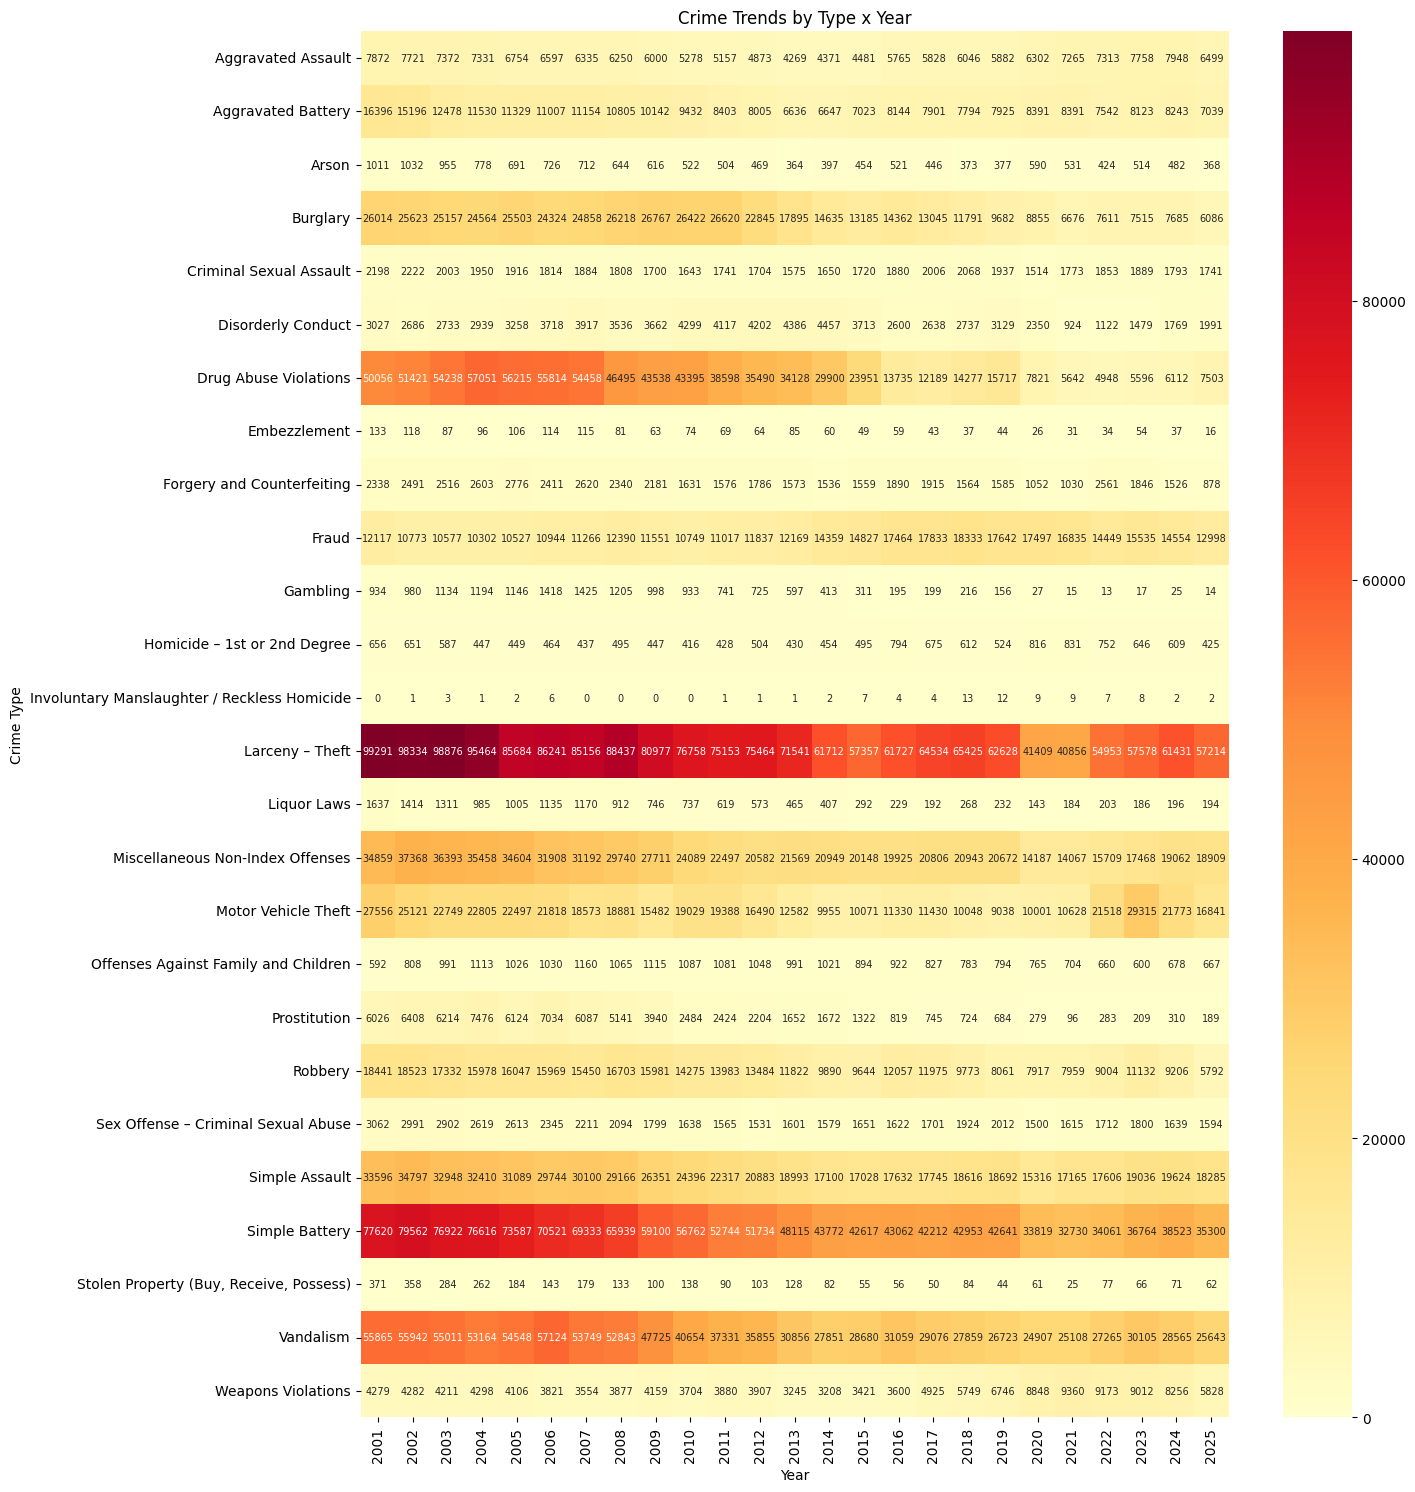

In [41]:
# Heatmap
plt.figure(figsize=(14,18))
sns.heatmap(pivot_year, cmap='YlOrRd', annot_kws={"size": 7}, annot=True, fmt='g')
plt.title("Crime Trends by Type x Year") 
plt.xlabel("Year") 
plt.ylabel("Crime Type") 
plt.show()

In [42]:
# create a weekday & type of crime counts by FBI code description
crime_time = (df_crime.pivot_table(index='fbi_code_desc', columns='time_of_day', aggfunc='size', fill_value=0))
# Reorder Mon - Sun chronologically
crime_time = crime_time.reindex(columns=time_labels)
# display
crime_time.head()

time_of_day,Late Night,Early Morning,Morning,Afternoon,Evening,Night
fbi_code_desc,,,,,,
Aggravated Assault,21732,10423,22920,31702,35996,34494
Aggravated Battery,50157,17475,23834,38113,48317,57780
Arson,4577,2514,1234,1266,1735,3175
Burglary,53835,58098,97489,88223,81916,64377
Criminal Sexual Assault,16593,5033,4126,5433,6124,8673


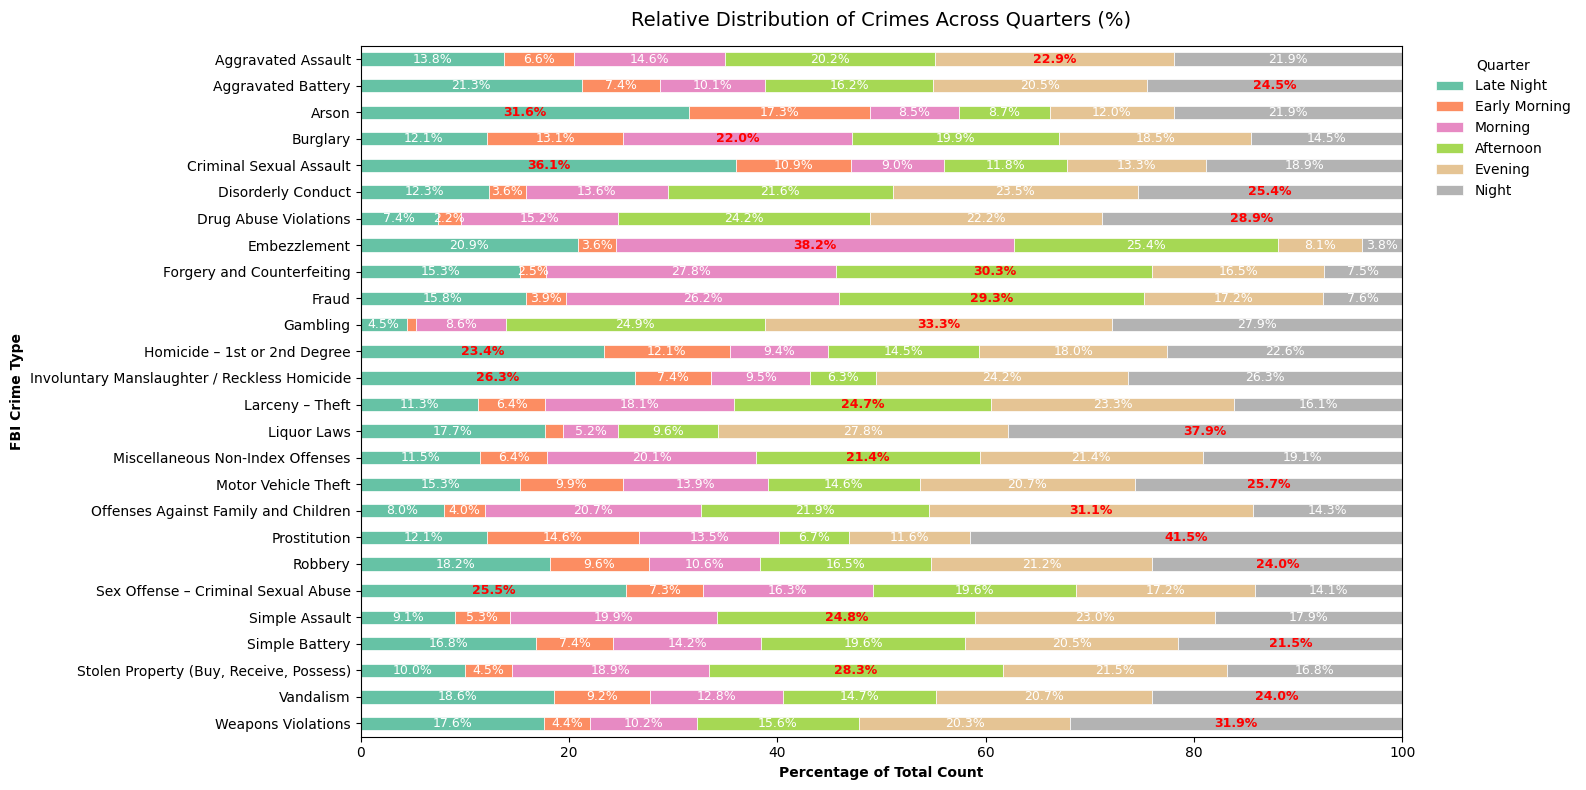

In [43]:
# plot
stacked_bar_plot(crime_time, figsize=(16,8))

In [44]:
# # Convert all columns to PyArrow dtypes
# df_melted = df_melted.convert_dtypes(dtype_backend='pyarrow')
# Melt the dataframe for plotting
df_melted = crime_time.reset_index().melt(id_vars='fbi_code_desc', var_name='time_of_day', value_name='count')
# Convert entire DataFrame to standard NumPy dtypes for plotting
df_melted = df_melted.convert_dtypes(dtype_backend='numpy_nullable')
# display
df_melted.head()

,fbi_code_desc,time_of_day,count
0,Aggravated Assault,Late Night,21732
1,Aggravated Battery,Late Night,50157
2,Arson,Late Night,4577
3,Burglary,Late Night,53835
4,Criminal Sexual Assault,Late Night,16593


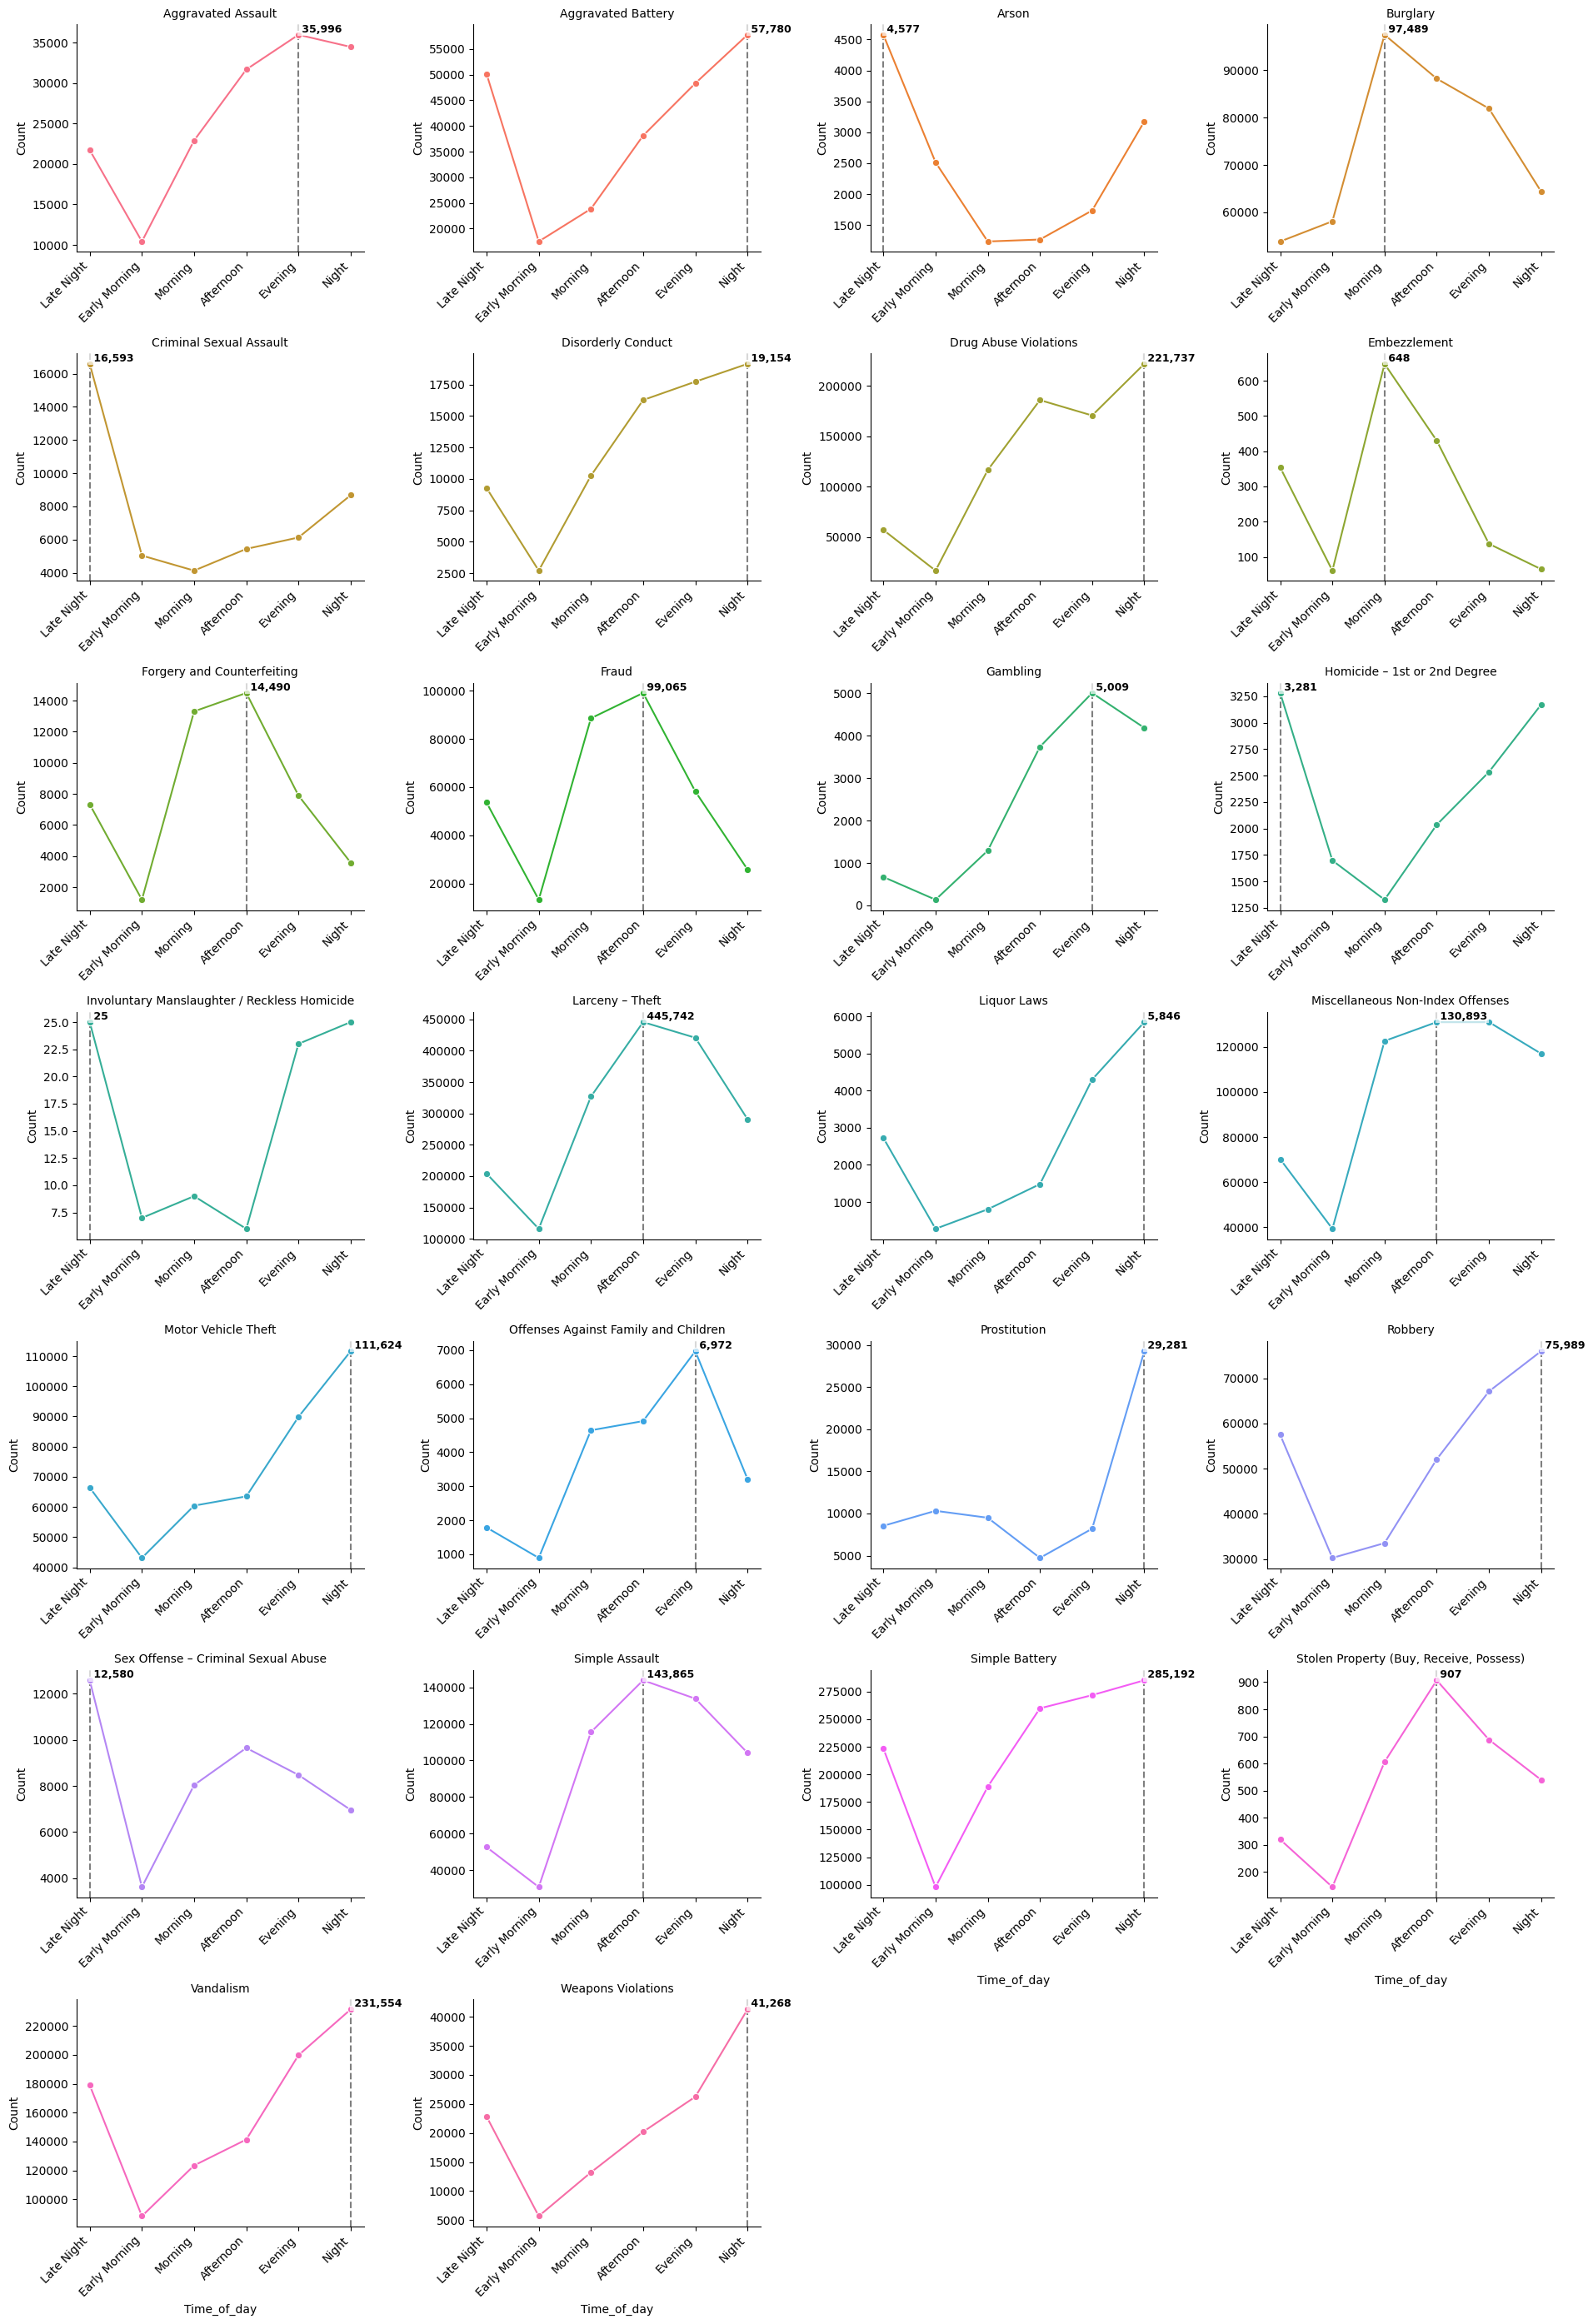

In [45]:
# plot
line_plot(df_melted,'fbi_code_desc',  'time_of_day', 'count')

In [46]:
# create a weekday & type of crime counts by FBI code description
crime_week = (df_crime.pivot_table(index='fbi_code_desc', columns='day_of_week', aggfunc='size', fill_value=0))
# Reorder Mon - Sun chronologically
crime_week = crime_week.reindex(columns=days)
# display
crime_week.head()

day_of_week,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
fbi_code_desc,,,,,,,
Aggravated Assault,22107,22036,22203,21774,21695,23382,24070
Aggravated Battery,31039,30315,30191,30416,32544,39889,41282
Arson,2084,2069,1951,1878,1920,2255,2344
Burglary,68155,66856,66678,66139,69865,55292,50953
Criminal Sexual Assault,6184,5975,5937,5971,6553,7612,7750


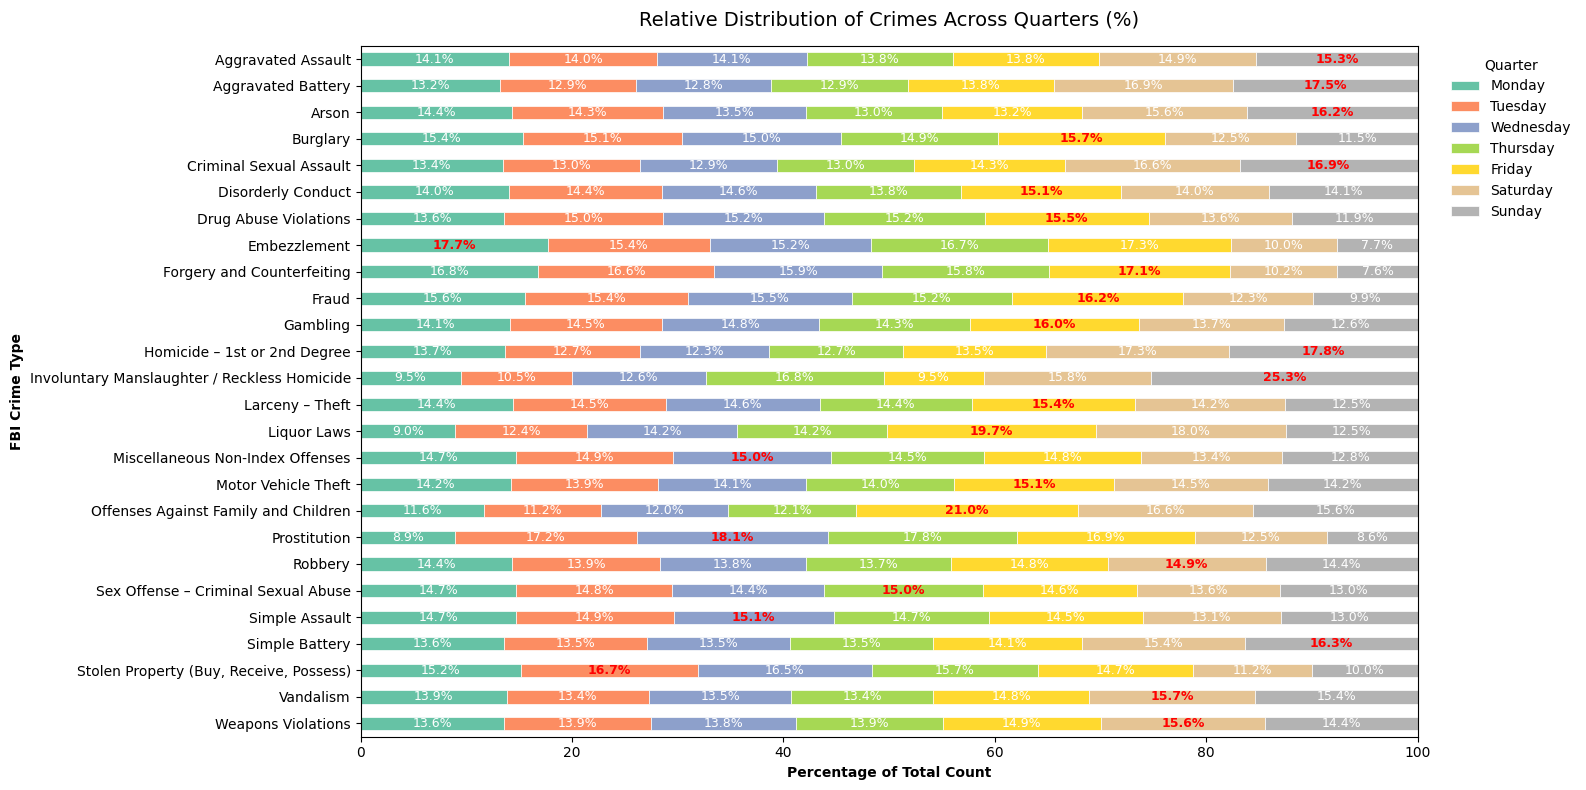

In [47]:
# plot
stacked_bar_plot(crime_week, figsize=(16,8))

In [48]:
# # Convert all columns to PyArrow dtypes
# df_melted = df_melted.convert_dtypes(dtype_backend='pyarrow')
# Melt the dataframe for plotting
df_melted = crime_week.reset_index().melt(id_vars='fbi_code_desc', var_name='day_of_week', value_name='count')
# Convert entire DataFrame to standard NumPy dtypes for plotting
df_melted = df_melted.convert_dtypes(dtype_backend='numpy_nullable')
# display
df_melted.head()

,fbi_code_desc,day_of_week,count
0,Aggravated Assault,Monday,22107
1,Aggravated Battery,Monday,31039
2,Arson,Monday,2084
3,Burglary,Monday,68155
4,Criminal Sexual Assault,Monday,6184


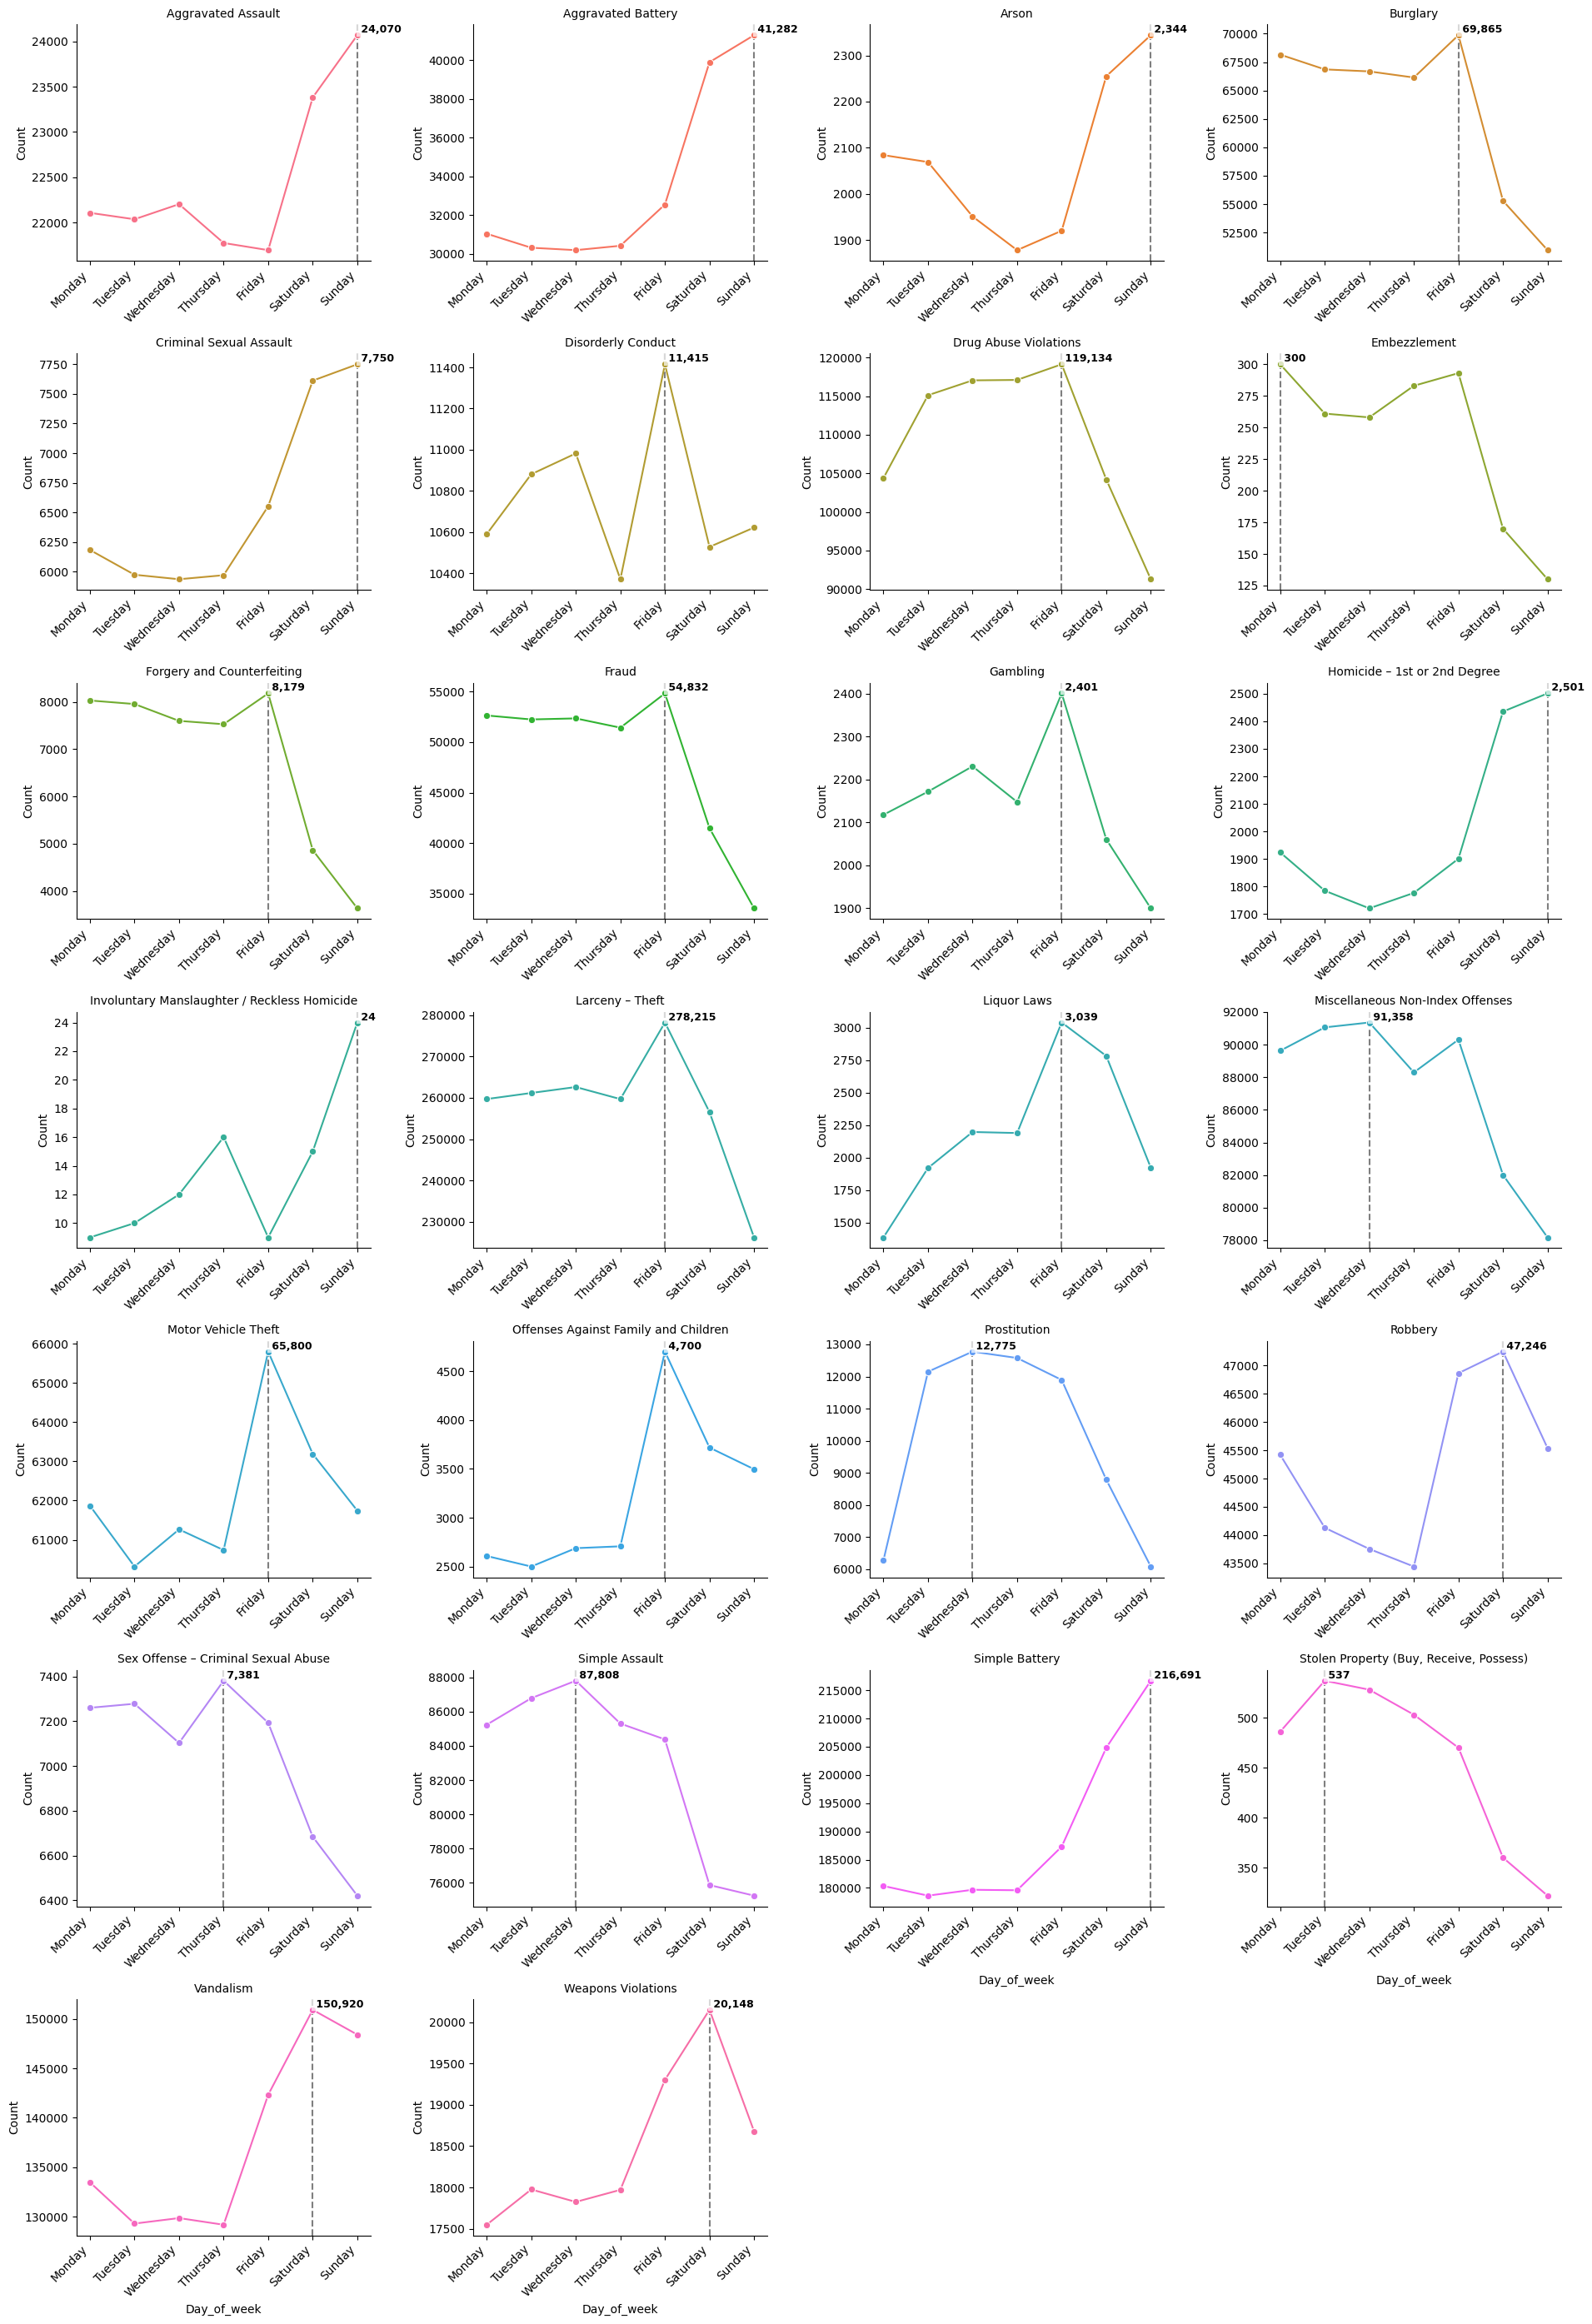

In [49]:
# plot
line_plot(df_melted,'fbi_code_desc',  'day_of_week', 'count')

In [50]:
# create a month & type of crime counts by FBI code description
crime_month = (df_crime.pivot_table(index='fbi_code_desc',columns='month',aggfunc='size', fill_value=0))
# Reorder months chronologically
crime_month = crime_month.reindex(columns=months)
# display
crime_month.head()

month,January,February,March,April,May,June,July,August,September,October,November,December
fbi_code_desc,,,,,,,,,,,,
Aggravated Assault,10785,9935,12533,13199,14844,15022,15607,14815,14274,13666,11680,10907
Aggravated Battery,14935,13383,17973,19610,22639,24422,25403,23598,21294,20754,16729,14936
Arson,1039,903,1222,1208,1365,1366,1471,1298,1254,1228,1122,1025
Burglary,34470,27191,31714,33095,37994,37792,41310,42588,40303,41467,38796,37218
Criminal Sexual Assault,4915,3122,3510,3467,3923,4174,4284,4218,3934,3855,3437,3143


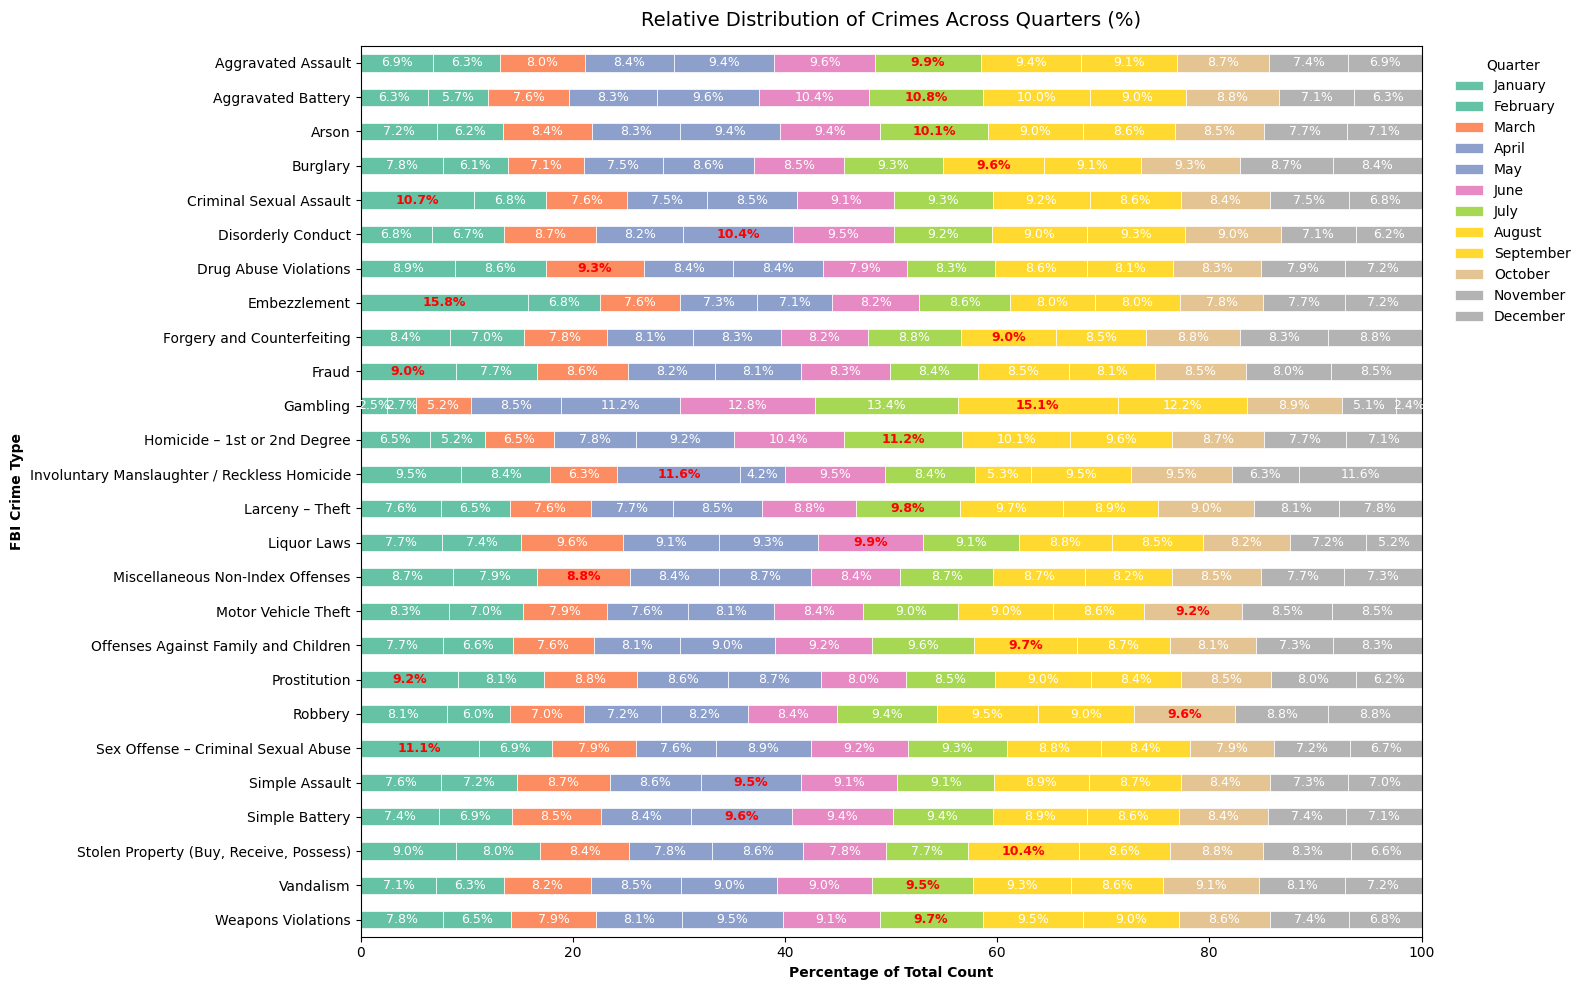

In [51]:
# plot
stacked_bar_plot(crime_month, figsize=(16,10))

In [52]:
# # Convert all columns to PyArrow dtypes
# df_melted = df_melted.convert_dtypes(dtype_backend='pyarrow')
# Melt the dataframe for plotting
df_melted = crime_month.reset_index().melt(id_vars='fbi_code_desc', var_name='month', value_name='count')
# Convert entire DataFrame to standard NumPy dtypes for plotting
df_melted = df_melted.convert_dtypes(dtype_backend='numpy_nullable')
# display
df_melted.head()

,fbi_code_desc,month,count
0,Aggravated Assault,January,10785
1,Aggravated Battery,January,14935
2,Arson,January,1039
3,Burglary,January,34470
4,Criminal Sexual Assault,January,4915


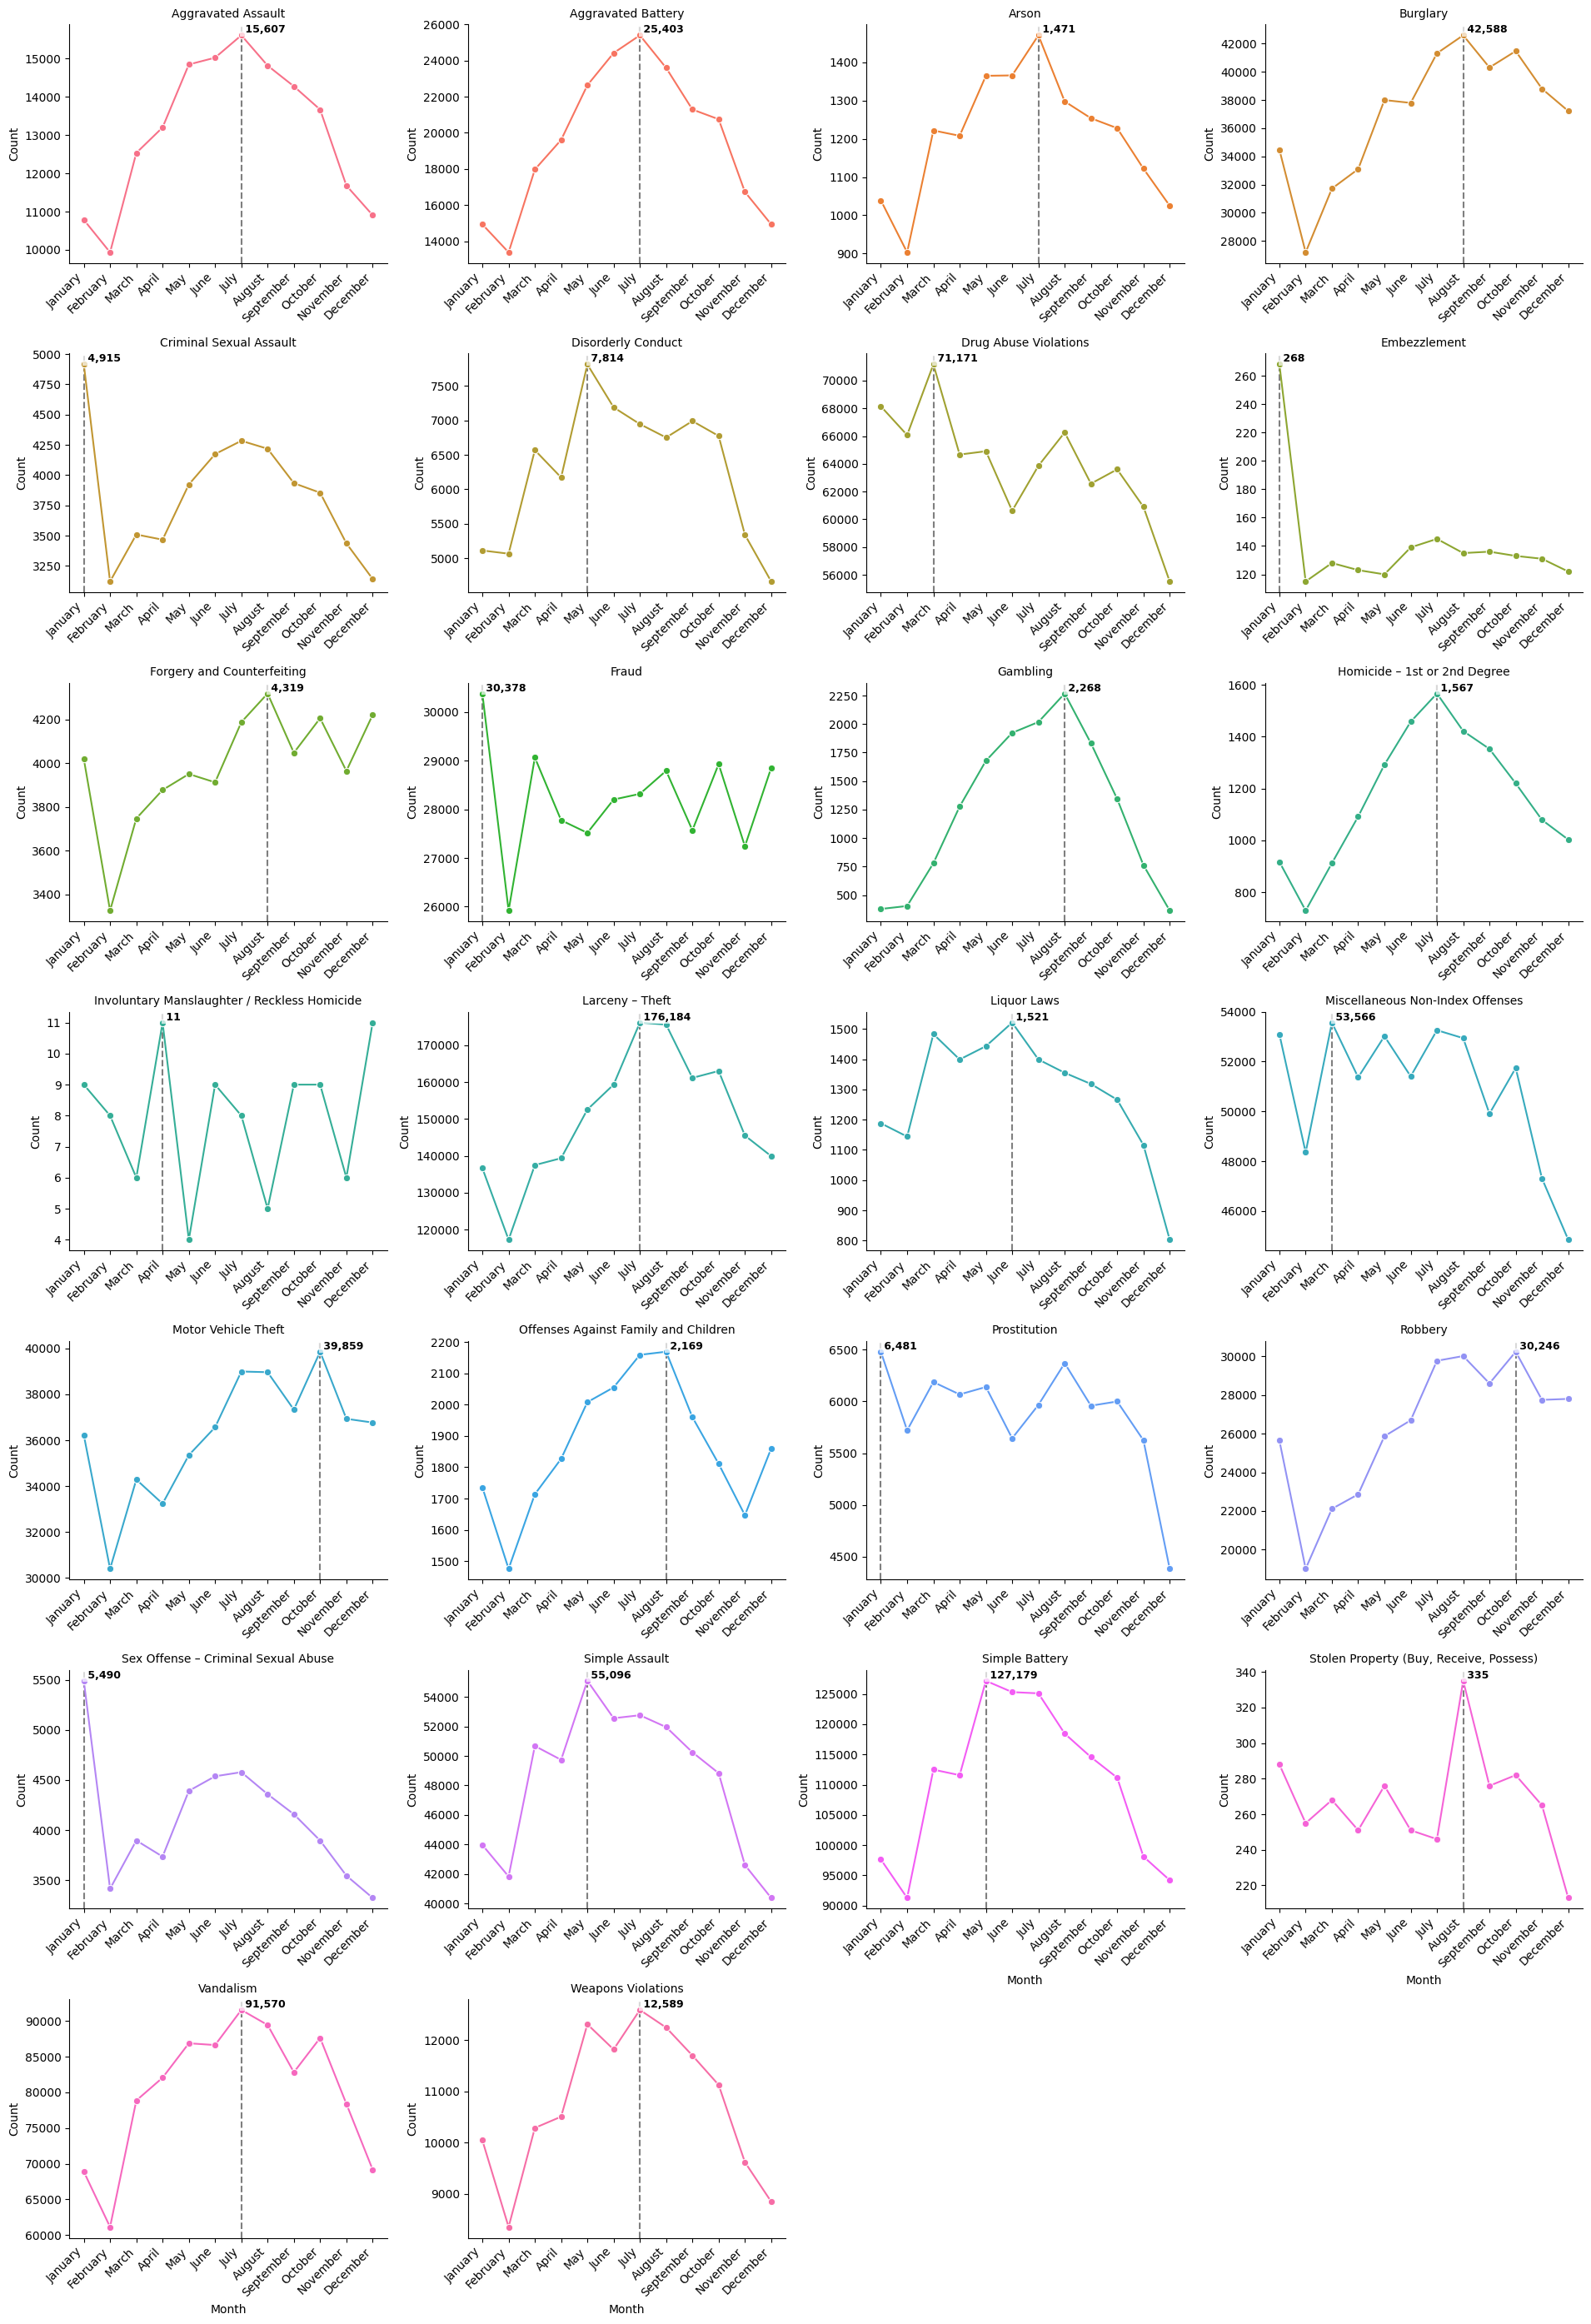

In [53]:
# plot
line_plot(df_melted,'fbi_code_desc',  'month', 'count')

In [54]:
# Define quarters once
quarter = ['Q1', 'Q2', 'Q3', 'Q4']

# Create quarter & type of crime counts by FBI code description
crime_qtr = (df_crime.pivot_table(index='fbi_code_desc', columns='quarter', aggfunc='size', fill_value=0).reindex(columns=quarter))
# display
crime_qtr.head()

quarter,Q1,Q2,Q3,Q4
fbi_code_desc,,,,
Aggravated Assault,33253,43065,44696,36253
Aggravated Battery,46291,66671,70295,52419
Arson,3164,3939,4023,3375
Burglary,93375,108881,124201,117481
Criminal Sexual Assault,11547,11564,12436,10435


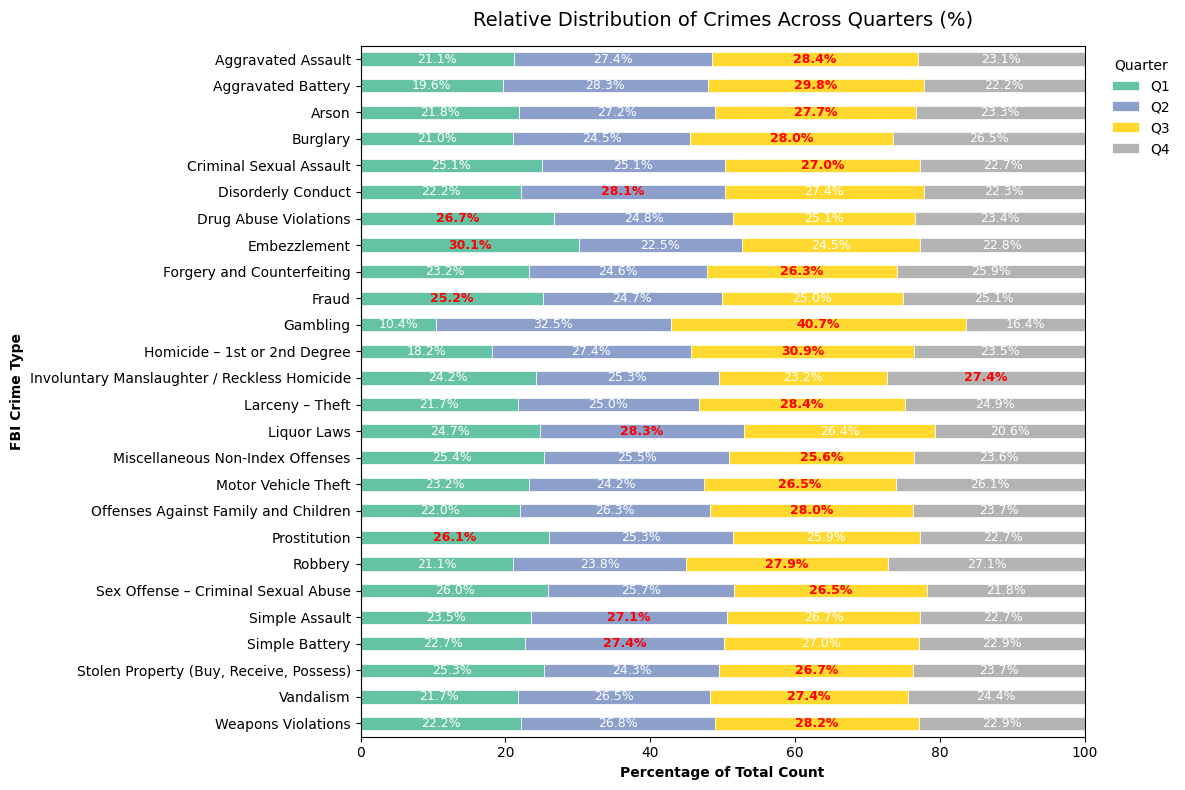

In [55]:
# plot
stacked_bar_plot(crime_qtr)

In [56]:
# # Convert all columns to PyArrow dtypes
# df_melted = df_melted.convert_dtypes(dtype_backend='pyarrow')
# Melt the dataframe for plotting
df_melted = crime_qtr.reset_index().melt(id_vars='fbi_code_desc', var_name='quarter', value_name='count')
# Convert entire DataFrame to standard NumPy dtypes for plotting
df_melted = df_melted.convert_dtypes(dtype_backend='numpy_nullable')
# display
df_melted.head()

,fbi_code_desc,quarter,count
0,Aggravated Assault,Q1,33253
1,Aggravated Battery,Q1,46291
2,Arson,Q1,3164
3,Burglary,Q1,93375
4,Criminal Sexual Assault,Q1,11547


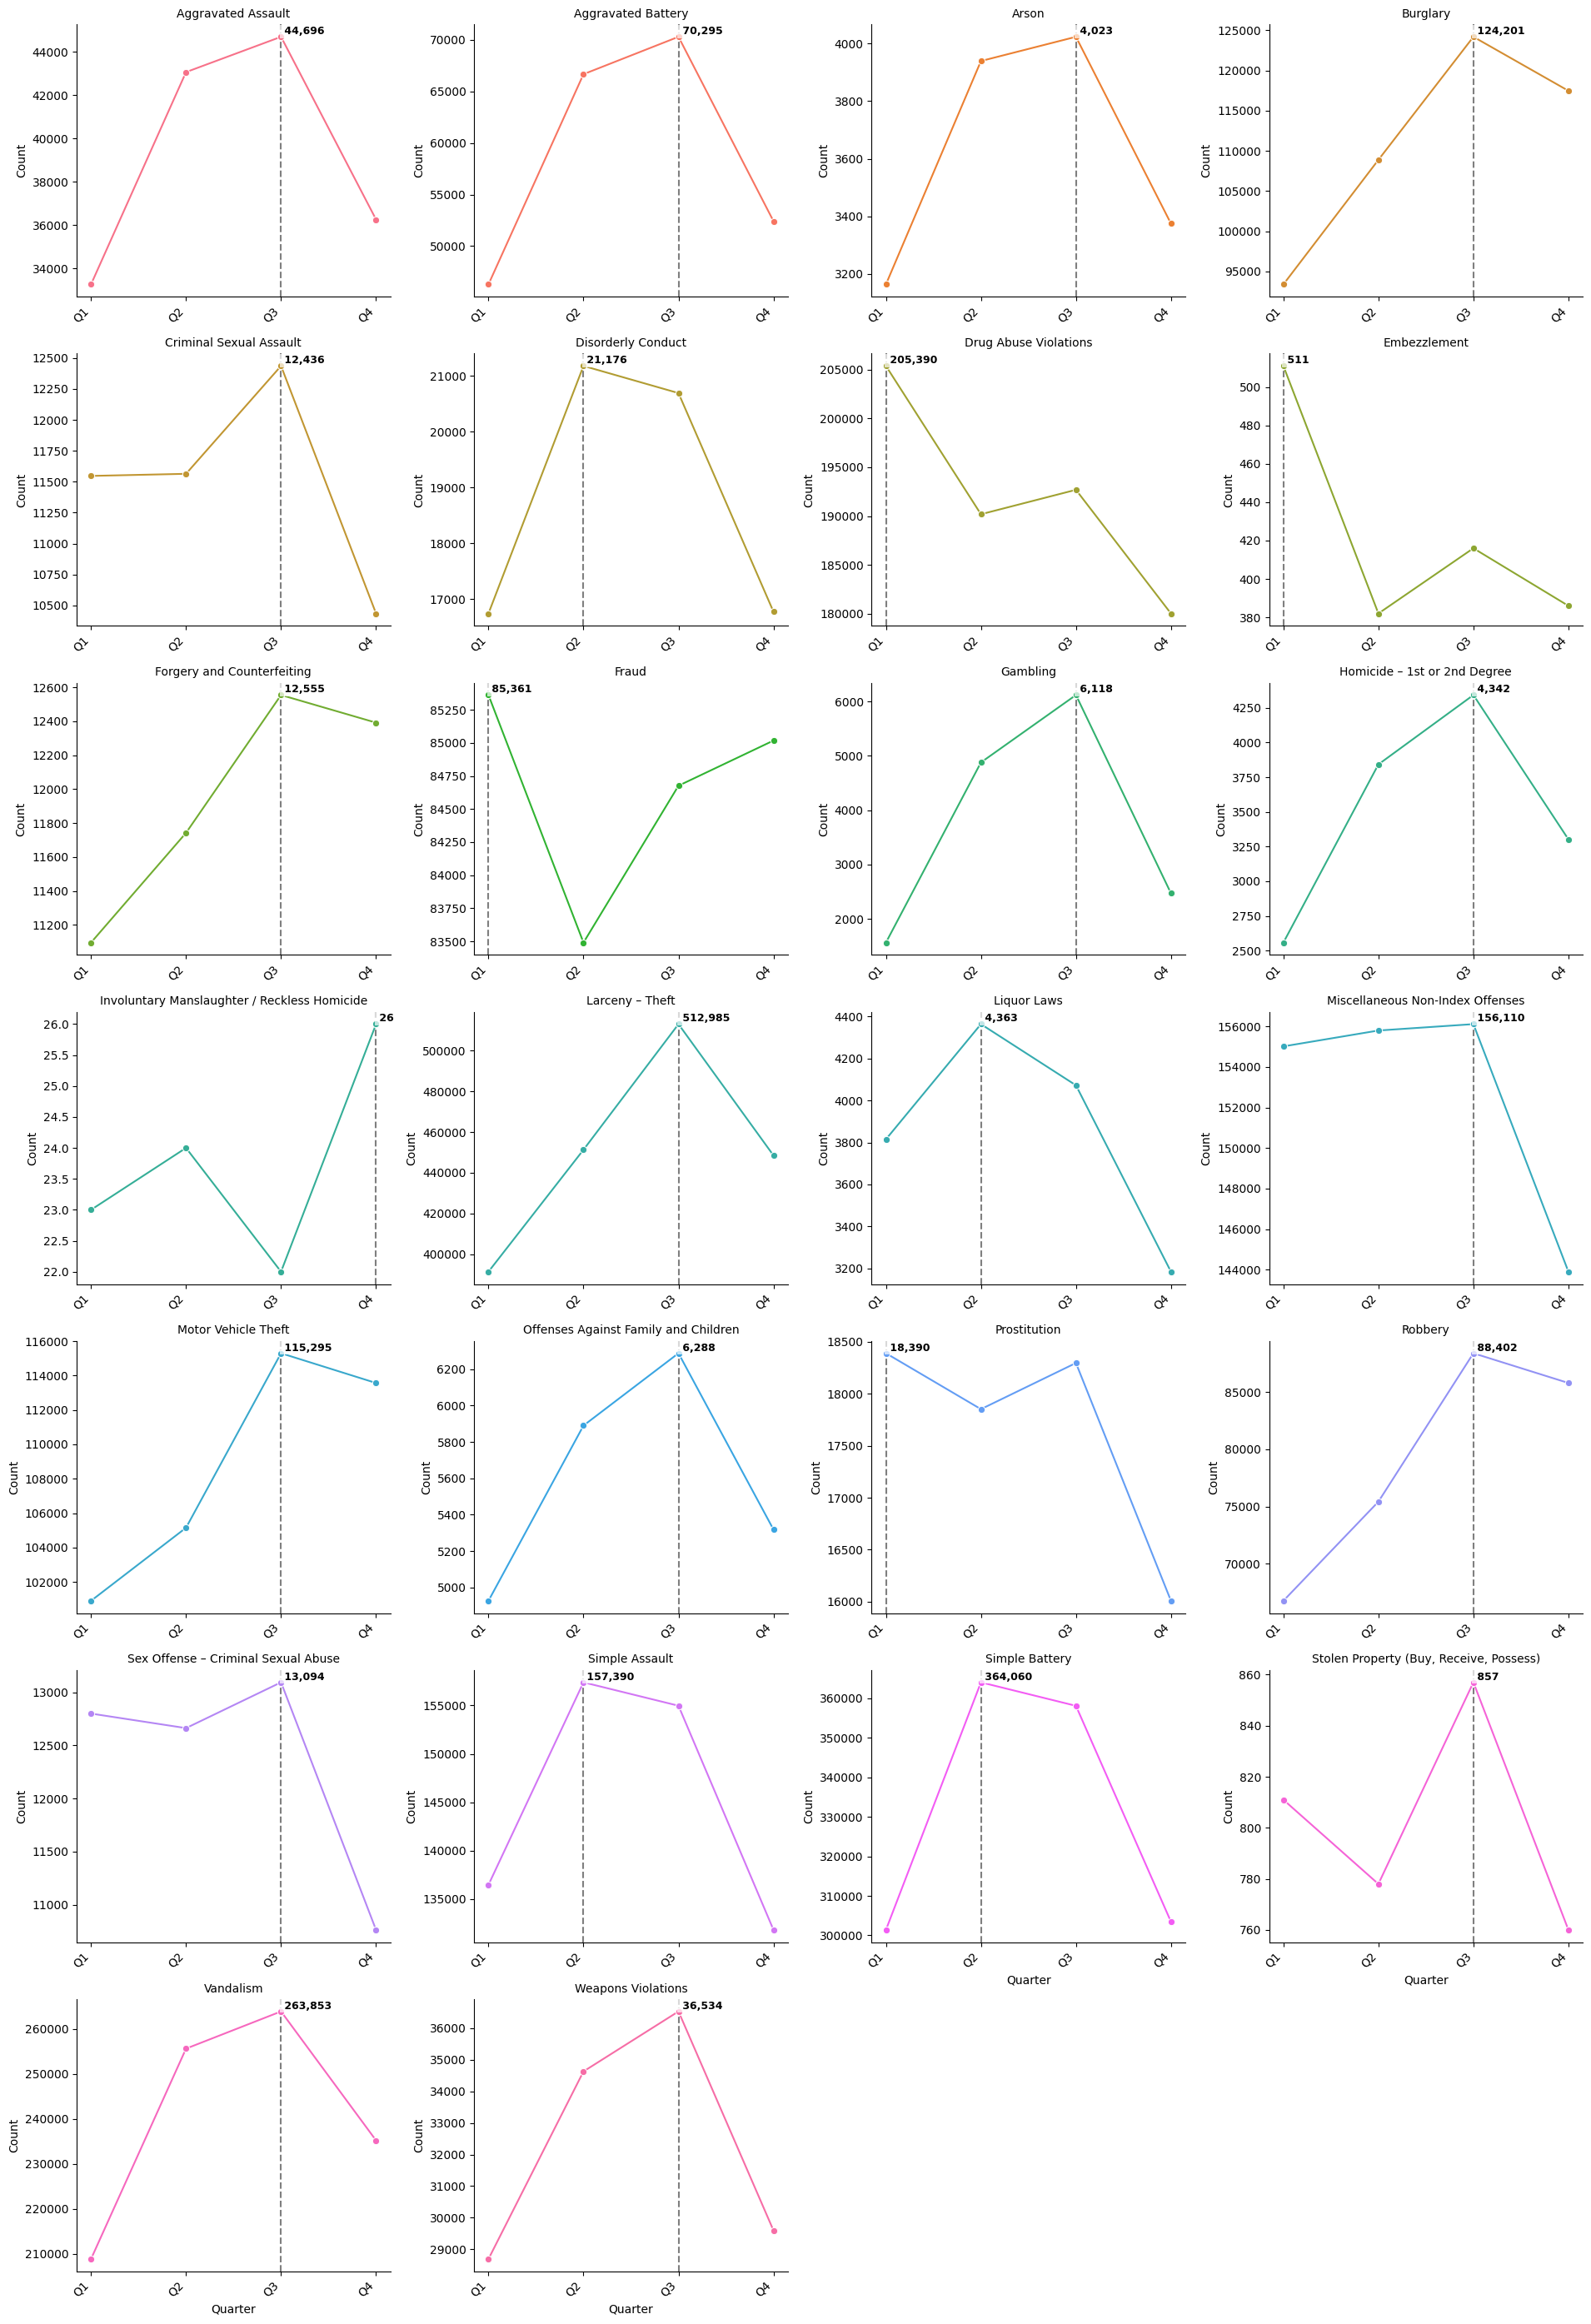

In [57]:
# plot
line_plot(df_melted,'fbi_code_desc',  'quarter', 'count')

## Total Time

In [58]:
# total elapsed time
elapsed = time.time() - start
print(f"{elapsed:.2f}s to process {df_crime.shape[0]:,} rows")

43.48s to process 8,486,097 rows


In [59]:
# aggregate data
aggregate = df_crime.groupby(['year','fbi_code_desc', 'primary_neighborhood']).size().unstack().fillna(0)
aggregate.head()

primary_neighborhood          Albany Park  Andersonville  Archer Heights  \
year fbi_code_desc                                                         
2001 Aggravated Assault              56.0            7.0            16.0   
     Aggravated Battery             111.0            7.0            33.0   
     Arson                           12.0            1.0             3.0   
     Burglary                       245.0           59.0           119.0   
     Criminal Sexual Assault         26.0            0.0             7.0   

primary_neighborhood          Armour Square  Ashburn  Auburn Gresham  Austin  \
year fbi_code_desc                                                             
2001 Aggravated Assault                11.0     64.0           252.0   459.0   
     Aggravated Battery                40.0     66.0           478.0   944.0   
     Arson                              4.0      8.0            14.0    72.0   
     Burglary                          58.0    249.0           811.0   936.0   
     Criminal Sexual Assault            3.0     14.0            62.0   168.0   

primary_neighborhood          Avalon Park  Avondale  Belmont Cragin  Beverly  \
year fbi_code_desc                                                             
2001 Aggravated Assault              38.0      69.0           149.0     21.0   
     Aggravated Battery              83.0     130.0           220.0     18.0   
     Arson                            3.0      18.0            27.0      1.0   
     Burglary                       122.0     420.0           669.0    138.0   
     Criminal Sexual Assault          5.0      20.0            28.0      5.0   

primary_neighborhood          Boystown  Bridgeport  Brighton Park  Bucktown  \
year fbi_code_desc                                                            
2001 Aggravated Assault            4.0        37.0           70.0      24.0   
     Aggravated Battery           10.0        65.0          140.0      34.0   
     Arson                         1.0        20.0           15.0       4.0   
     Burglary                     26.0       331.0          397.0     275.0   
     Criminal Sexual Assault       0.0         9.0           16.0       9.0   

primary_neighborhood          Burnside  Calumet Heights  Chatham  \
year fbi_code_desc                                                 
2001 Aggravated Assault           15.0             49.0    139.0   
     Aggravated Battery           34.0             84.0    280.0   
     Arson                         7.0              6.0     18.0   
     Burglary                     26.0            161.0    529.0   
     Criminal Sexual Assault       7.0             14.0     43.0   

primary_neighborhood          Chicago Lawn  Chinatown  Clearing  Douglas  \
year fbi_code_desc                                                         
2001 Aggravated Assault              175.0        6.0      21.0    112.0   
     Aggravated Battery              333.0       17.0      25.0    336.0   
     Arson                            29.0        0.0       9.0      6.0   
     Burglary                        826.0       33.0     154.0    177.0   
     Criminal Sexual Assault          64.0        1.0       7.0     39.0   

primary_neighborhood          Dunning  East Side  East Village  Edgewater  \
year fbi_code_desc                                                          
2001 Aggravated Assault          30.0       42.0          11.0       45.0   
     Aggravated Battery          27.0       77.0          37.0       72.0   
     Arson                        4.0        6.0           4.0       10.0   
     Burglary                   204.0      145.0         132.0      284.0   
     Criminal Sexual Assault      8.0        7.0           1.0       26.0   

primary_neighborhood          Edison Park  Englewood  Fuller Park  Gage Park  \
year fbi_code_desc                                                             
2001 Aggravated Assault               2.0      637.0         29.0       53.0   
 

In [60]:
# reset index
reset_agg = aggregate.reset_index()
reset_agg.head()

primary_neighborhood,year,fbi_code_desc,Albany Park,Andersonville,Archer Heights,Armour Square,Ashburn,Auburn Gresham,Austin,Avalon Park,Avondale,Belmont Cragin,Beverly,Boystown,Bridgeport,Brighton Park,Bucktown,Burnside,Calumet Heights,Chatham,Chicago Lawn,Chinatown,Clearing,Douglas,Dunning,East Side,East Village,Edgewater,Edison Park,Englewood,Fuller Park,Gage Park,Galewood,Garfield Park,Garfield Ridge,Gold Coast,Grand Boulevard,Grand Crossing,Grant Park,Greektown,Hegewisch,Hermosa,Humboldt Park,Hyde Park,Irving Park,Jackson Park,Jefferson Park,Kenwood,Lake View,Lincoln Park,Lincoln Square,"Little Italy, UIC",Little Village,Logan Square,Loop,Lower West Side,Magnificent Mile,Mckinley Park,Millenium Park,Montclare,Morgan Park,Mount Greenwood,Museum Campus,Near South Side,New City,North Center,North Lawndale,North Park,Norwood Park,O'Hare,Oakland,Old Town,Portage Park,Printers Row,Pullman,River North,Riverdale,Rogers Park,Roseland,Rush & Division,"Sauganash,Forest Glen",Sheffield & DePaul,South Chicago,South Deering,South Shore,Streeterville,Ukrainian Village,United Center,Uptown,Washington Heights,Washington Park,West Elsdon,West Lawn,West Loop,West Pullman,West Ridge,West Town,Wicker Park,Woodlawn,Wrigleyville
0,2001,Aggravated Assault,56.0,7.0,16.0,11.0,64.0,252.0,459.0,38.0,69.0,149.0,21.0,4.0,37.0,70.0,24.0,15.0,49.0,139.0,175.0,6.0,21.0,112.0,30.0,42.0,11.0,45.0,2.0,637.0,29.0,53.0,13.0,277.0,55.0,1.0,180.0,229.0,1.0,2.0,22.0,44.0,348.0,34.0,64.0,7.0,20.0,43.0,55.0,35.0,44.0,88.0,164.0,158.0,38.0,143.0,10.0,35.0,1.0,21.0,65.0,21.0,0.0,43.0,238.0,46.0,270.0,16.0,21.0,7.0,27.0,30.0,63.0,5.0,29.0,85.0,63.0,123.0,273.0,18.0,7.0,10.0,170.0,61.0,296.0,9.0,17.0,88.0,104.0,112.0,117.0,19.0,38.0,33.0,190.0,66.0,61.0,63.0,154.0,4.0
1,2001,Aggravated Battery,111.0,7.0,33.0,40.0,66.0,478.0,944.0,83.0,130.0,220.0,18.0,10.0,65.0,140.0,34.0,34.0,84.0,280.0,333.0,17.0,25.0,336.0,27.0,77.0,37.0,72.0,6.0,1552.0,65.0,172.0,18.0,697.0,85.0,11.0,624.0,494.0,4.0,7.0,16.0,122.0,798.0,49.0,145.0,17.0,17.0,87.0,84.0,49.0,54.0,185.0,375.0,343.0,53.0,253.0,6.0,57.0,0.0,21.0,90.0,10.0,1.0,115.0,484.0,58.0,564.0,20.0,10.0,13.0,79.0,34.0,59.0,3.0,67.0,302.0,155.0,177.0,562.0,21.0,10.0,12.0,341.0,89.0,570.0,18.0,34.0,230.0,208.0,140.0,377.0,30.0,61.0,23.0,399.0,88.0,163.0,149.0,366.0,12.0
2,2001,Arson,12.0,1.0,3.0,4.0,8.0,14.0,72.0,3.0,18.0,27.0,1.0,1.0,20.0,15.0,4.0,7.0,6.0,18.0,29.0,0.0,9.0,6.0,4.0,6.0,4.0,10.0,1.0,73.0,2.0,12.0,1.0,29.0,7.0,0.0,10.0,22.0,0.0,0.0,4.0,23.0,43.0,3.0,17.0,0.0,2.0,4.0,7.0,1.0,5.0,8.0,37.0,24.0,0.0,23.0,0.0,7.0,0.0,5.0,7.0,3.0,0.0,3.0,40.0,9.0,30.0,1.0,1.0,1.0,2.0,1.0,11.0,0.0,2.0,7.0,4.0,13.0,37.0,0.0,1.0,3.0,14.0,9.0,15.0,0.0,2.0,2.0,13.0,8.0,12.0,5.0,11.0,1.0,17.0,8.0,14.0,7.0,18.0,0.0
3,2001,Burglary,245.0,59.0,119.0,58.0,249.0,811.0,936.0,122.0,420.0,669.0,138.0,26.0,331.0,397.0,275.0,26.0,161.0,529.0,826.0,33.0,154.0,177.0,204.0,145.0,132.0,284.0,33.0,1380.0,70.0,342.0,111.0,517.0,293.0,23.0,364.0,568.0,3.0,7.0,54.0,218.0,861.0,165.0,389.0,29.0,131.0,132.0,612.0,369.0,264.0,204.0,580.0,672.0,202.0,263.0,26.0,217.0,1.0,85.0,213.0,56.0,4.0,71.0,619.0,332.0,437.0,93.0,138.0,44.0,50.0,128.0,455.0,14.0,80.0,299.0,106.0,382.0,606.0,37.0,79.0,92.0,359.0,136.0,776.0,61.0,165.0,131.0,261.0,257.0,212.0,156.0,207.0,146.0,485.0,334.0,395.0,440.0,329.0,47.0
4,2001,Criminal Sexual Assault,26.0,0.0,7.0,3.0,14.0,62.0,168.0,5.0,20.0,28.0,5.0,0.0,9.0,16.0,9.0,7.0,14.0,43.0,64.0,1.0,7.0,39.0,8.0,7.0,1.0,26.0,1.0,156.0,3.0,14.0,5.0,67.0,16.0,3.0,54.0,57.0,0.0,1.0,6.0,24.0,76.0,14.0,32.0,5.0,7.0,13.0,15.0,12.0,12.0,20.0,41.0,43.0,14.0,15.0,0.0,6.0,0.0,3.0,9.0,1.0,2.0,11.0,57.0,7.0,57.0,6.0,3.0,3.0,6.0,12.0,14.0,0.0,12.0,25.0,13.0,36.0,70.0,5.0,4.0,6.0,50.0,16.0,71.0,3.0,4.0,13.0,30.0,21.0,46.0,6.0,6.0,10.0,40.0,30.0,13.0,27.0,44.0,1.0


In [61]:
# rearrange data
neighborhood_cols = reset_agg.columns[2:]   # all neighborhood columns

df_long = reset_agg.melt(
    id_vars=['year', 'fbi_code_desc'],
    value_vars=neighborhood_cols,
    var_name='neighborhood',
    value_name='crime_count'
)
df_long.head()

,year,fbi_code_desc,neighborhood,crime_count
0,2001,Aggravated Assault,Albany Park,56.0
1,2001,Aggravated Battery,Albany Park,111.0
2,2001,Arson,Albany Park,12.0
3,2001,Burglary,Albany Park,245.0
4,2001,Criminal Sexual Assault,Albany Park,26.0


In [62]:
# Calculate mean and standard deviation per year/type
stats = df_long.groupby(['year', 'fbi_code_desc'], observed=False)['crime_count'].agg(['mean', 'std']).fillna(0)

# Merge back and calculate Z-Score
df_long = df_long.merge(stats, on=['year', 'fbi_code_desc'])
df_long['z_score'] = (df_long['crime_count'] - df_long['mean']) / df_long['std']

# Find the most "Extreme" statistical outliers
extremes = df_long[df_long['year'] == '2025'].sort_values('z_score', ascending=False)

In [63]:
extremes[['neighborhood', 'fbi_code_desc', 'crime_count', 'z_score']].head(10)

,neighborhood,fbi_code_desc,crime_count,z_score
21277,Garfield Ridge,Prostitution,70.0,7.990041
60616,West Ridge,Involuntary Manslaughter / Reckless Homicide,1.0,6.892765
54166,Streeterville,Involuntary Manslaughter / Reckless Homicide,1.0,6.892765
4500,Austin,Homicide – 1st or 2nd Degree,47.0,5.934505
34164,Loop,Disorderly Conduct,175.0,5.667393
26425,Humboldt Park,Drug Abuse Violations,1164.0,5.354594
26442,Humboldt Park,"Stolen Property (Buy, Receive, Possess)",7.0,5.323386
18051,Englewood,Offenses Against Family and Children,51.0,5.212010
4507,Austin,Prostitution,46.0,5.172985
4491,Austin,Arson,30.0,5.163327


In [64]:
extremes

,year,fbi_code_desc,neighborhood,crime_count,mean,std,z_score
21277,2025,Prostitution,Garfield Ridge,70.0,1.928571,8.519535,7.990041
60616,2025,Involuntary Manslaughter / Reckless Homicide,West Ridge,1.0,0.020408,0.142119,6.892765
54166,2025,Involuntary Manslaughter / Reckless Homicide,Streeterville,1.0,0.020408,0.142119,6.892765
4500,2025,Homicide – 1st or 2nd Degree,Austin,47.0,4.326531,7.190738,5.934505
34164,2025,Disorderly Conduct,Loop,175.0,20.295918,27.297222,5.667393
26425,2025,Drug Abuse Violations,Humboldt Park,1164.0,76.346939,203.125227,5.354594
26442,2025,"Stolen Property (Buy, Receive, Possess)",Humboldt Park,7.0,0.632653,1.196108,5.323386
18051,2025,Offenses Against Family and Children,Englewood,51.0,6.785714,8.483155,5.212010
4507,2025,Prostitution,Austin,46.0,1.928571,8.519535,5.172985
4491,2025,Arson,Austin,30.0,3.755102,5.082943,5.163327


In [65]:
# fill in NaNs
df_crime['location_description'] = df_crime.location_description.fillna("Unknown")
df_crime['district'] = df_crime.district.fillna(999)
df_crime['ward'] = df_crime.ward.fillna(999)
df_crime['community_area'] = df_crime.community_area.fillna(999)

In [66]:
# check for nulls
df_crime.isnull().values.any()

np.True_

In [67]:
# remove features
cols = ['case_number', 'date', 'block', 'primary_type', 'description', 
        'location_description', 'updated_on', 'primary_neighborhood', 'secondary_neighborhood']

In [68]:
aggregate.loc[
    [(2024, 'ROBBERY'), (2024, 'HOMICIDE'),
     (2025, 'ROBBERY'), (2025, 'HOMICIDE')]
]


KeyError: "None of [MultiIndex([(2024,  'ROBBERY'),\n            (2024, 'HOMICIDE'),\n            (2025,  'ROBBERY'),\n            (2025, 'HOMICIDE')],\n           names=['year', 'fbi_code_desc'])] are in the [index]"

In [ ]:
aggregate.loc[(slice(2024, 2025), ['ROBBERY', 'HOMICIDE']), :]

In [ ]:
reset_agg = aggregate.reset_index()
reset_agg.head()

In [ ]:
# rearrange data
neighborhood_cols = reset_agg.columns[2:]   # all neighborhood columns

df_long = reset_agg.melt(
    id_vars=['year', 'primary_type'],
    value_vars=neighborhood_cols,
    var_name='neighborhood',
    value_name='crime_count'
)
df_long.head()

In [ ]:
extremes.describe(include='all').T

## Save using Native PyArrow IPC

In [69]:
# 1. Convert Pandas DataFrame to PyArrow Table
table = pa.Table.from_pandas(df_crime)

# Save as Arrow IPC stream (faster than pickle)
with open('../Data/crime_data.arrow', 'wb') as f:
    with ipc.new_file(f, table.schema) as writer:
        writer.write_table(table)